### Exploratory Data Analysis on NIFTY-50 Stock Market Data

#### This is my first project on NIFTY-50 Stock Market Data Analysis
1. Data loading and initial inspection
2. Data quality assessment
3. Data cleaning
4. Univariate analysis
5. Bivariate analysis
6. Correlation analysis
7. Hypothesis testing (t-test, z-test, chi-square test)
8. Summary of findings


### The Big Picture — Why All of This Matters
``` text
Raw Data
    ↓
Univariate  →  "What does each variable look like?"
    ↓              (distributions, outliers, skewness)
Bivariate   →  "How do variables relate to each other?"
    ↓              (scatter plots, box plots, grouped analysis)
Correlation →  "How strong are those relationships?"
    ↓              (heatmap, correlation values)
Hypothesis  →  "Are these relationships statistically real
Testing            or just random chance?"
    ↓
Feature     →  "Which variables actually help predict
Engineering        tomorrow's return?"
```


### What the stock data columns mean

- `Date`: the trading day. Time matters because stock returns depend on sequence.
- `Symbol`: the stock ticker. This lets us compare patterns across different companies.
- `Open`, `High`, `Low`, `Close`: the day’s price path. `Open` is the first traded price, `Close` is the last traded price, and `High`/`Low` are the intraday extremes.
- `Prev Close`: yesterday’s closing price, useful to measure overnight changes.
- `Last`: the final traded price at close, often very close to `Close`.
- `VWAP`: the volume-weighted average price, which shows the average execution price adjusted for traded volume.
- `Volume`: how many shares changed hands, a proxy for liquidity and market interest.
- `Turnover`: total traded value, combining price and volume.
- `Trades`: number of individual trades; many small trades can indicate active participation.
- `Deliverable Volume` and `%Deliverble`: the amount of shares actually taken delivery, which can signal whether investors are holding for longer-term rather than just intraday speculation.

These features help us answer the central EDA question: "How does price movement relate to trading activity and market behavior?"

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (17, 7)
plt.rcParams['font.size'] = 14

1. Data Loading and Initial Inspection

Let start with loading the data understanding rows column and info on each column and statistics about the dataset

In [24]:
data = pd.read_csv("D:/NIFTY50_all.csv") 
data.tail()
print(f"Shape of the dataset: {data.shape}")
print(f"Number of rows: {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")

Shape of the dataset: (235192, 15)
Number of rows: 235192
Number of columns: 15


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235192 entries, 0 to 235191
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                235192 non-null  object 
 1   Symbol              235192 non-null  object 
 2   Series              235192 non-null  object 
 3   Prev Close          235192 non-null  float64
 4   Open                235192 non-null  float64
 5   High                235192 non-null  float64
 6   Low                 235192 non-null  float64
 7   Last                235192 non-null  float64
 8   Close               235192 non-null  float64
 9   VWAP                235192 non-null  float64
 10  Volume              235192 non-null  int64  
 11  Turnover            235192 non-null  float64
 12  Trades              120344 non-null  float64
 13  Deliverable Volume  219115 non-null  float64
 14  %Deliverble         219115 non-null  float64
dtypes: float64(11), int64(1), object(3

In [26]:
data.describe().round()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,235192.0,235192.0,235192.0,235192.0,235192.0,235192.0,235192.0,235192.0,2.351920e+05,120344.0,219115.0,219115.0
mean,1266.0,1268.0,1287.0,1247.0,1266.0,1267.0,1267.0,3045903.0,1.610138e+14,61964.0,1315098.0,1.0
std,2581.0,2585.0,2620.0,2547.0,2581.0,2582.0,2583.0,7333981.0,3.298085e+14,68665.0,2831670.0,0.0
min,0.0,8.0,10.0,8.0,9.0,9.0,9.0,3.0,1.047000e+07,11.0,5.0,0.0
25%,274.0,275.0,280.0,270.0,274.0,274.0,275.0,219010.0,1.612816e+13,21834.0,125383.0,0.0
50%,566.0,567.0,577.0,556.0,567.0,567.0,567.0,1010938.0,6.832603e+13,44068.0,501756.0,1.0
75%,1242.0,1243.0,1263.0,1222.0,1243.0,1242.0,1243.0,3019851.0,1.863835e+14,78936.0,1452233.0,1.0
max,32862.0,33400.0,33480.0,32468.0,32849.0,32862.0,32975.0,481058927.0,3.564334e+16,1643015.0,232530747.0,1.0


In [27]:
data.describe(include='object').round()

,Date,Symbol,Series
count,235192,235192,235192
unique,5306,65,1
top,2018-08-13,IOC,EQ
freq,49,5306,235192


## 2. Data Quality Assessment

We now examine the data for missing values, duplicates, and data type issues. Understanding data quality is essential before performing any analysis or hypothesis testing.

In [28]:
missing = pd.DataFrame({
    'Missing Values' : data.isnull().sum(),
    'Missing Values %' : (data.isnull().sum() / len(data) * 100).round() 
})
missing[missing['Missing Values'] > 0].sort_values('Missing Values',ascending=False)

,Missing Values,Missing Values %
Trades,114848,49.0
Deliverable Volume,16077,7.0
%Deliverble,16077,7.0


In [29]:
cols_with_missing = missing[missing['Missing Values'] > 0].index

In [30]:
cols_with_missing

Index(['Trades', 'Deliverable Volume', '%Deliverble'], dtype='object')

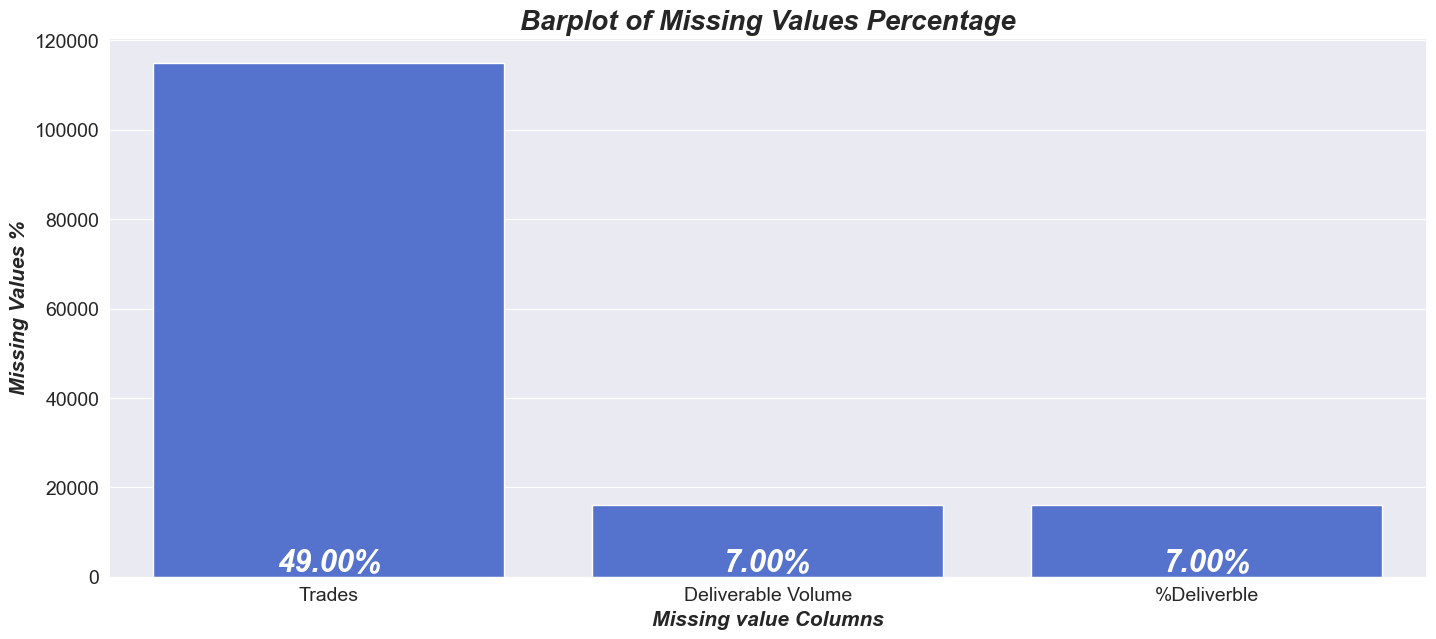

In [31]:
fig, ax = plt.subplots(figsize=(17,7))
sns.barplot(x=cols_with_missing,y=missing.loc[cols_with_missing,"Missing Values"],ax=ax,color='royalblue')
ax.set_title("Barplot of Missing Values Percentage",fontsize=20,fontdict={'fontweight':'bold','fontstyle':'oblique'})
ax.set_xlabel("Missing value Columns",fontsize=15,fontdict={'fontweight':'bold','fontstyle':'oblique'})
ax.set_ylabel("Missing Values %",fontsize=15,fontdict={'fontweight':'bold','fontstyle':'oblique'})
for i, column in enumerate(cols_with_missing):
    ax.text(i,missing.loc[column,"Missing Values %"],f"{missing.loc[column,'Missing Values %']:.2f}%",ha='center',va="bottom",fontsize=22,color='white',fontdict={'fontweight':'bold','fontstyle':'oblique'})


In [32]:
print(f"Number Duplicate Rows: {data.duplicated().sum()}")

Number Duplicate Rows: 0


In [33]:
cols_with_missing
data[cols_with_missing].info() # Datatype is Float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235192 entries, 0 to 235191
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Trades              120344 non-null  float64
 1   Deliverable Volume  219115 non-null  float64
 2   %Deliverble         219115 non-null  float64
dtypes: float64(3)
memory usage: 5.4 MB


## 3. Data Cleaning

- **Trades** : This columns has Highest missing values with `49%`. This column is almost half missing. Trade column will be dropped.
- **Deliverable Volume** & **%Deliverble** : These columns are similar and has the same missing values 7% column missing values will be replaced with the median and calculated percentage median.

In [34]:
data_copy = data.copy()

In [35]:
#Dropping Trade Column
data_copy.drop('Trades',inplace=True,axis=1)

In [36]:
print(f"Number of Columns: {data_copy.shape[1]}") # prvious column count is 15
data.head()

Number of Columns: 14


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


### Why median is robust
1. A statistic that is not heavily affected by outliers or extreme values.
2. The median is stable even when extreme values exist.
**Ex:** 10, 12, 14, 15, 100 - Median = 14

In [37]:
data_copy['Deliverable Volume'] = data_copy['Deliverable Volume'].fillna(data_copy['Deliverable Volume'].median())
data_copy['%Deliverble'] = (data_copy['Deliverable Volume']/data_copy['Volume'])*100

In [38]:
# Missing Values After Cleaning
missing = pd.DataFrame({
    'Missing Values' : data_copy.isnull().sum(),
    'Missing Values %' : (data_copy.isnull().sum() / len(data_copy) * 100).round() 
})
missing[missing['Missing Values'] > 0].sort_values('Missing Values',ascending=False)

,Missing Values,Missing Values %


In [39]:
data.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


In [40]:
print("Cleaned dataset shape:", data_copy.shape)
print("\nData types after cleaning:")
print(data_copy.dtypes)

Cleaned dataset shape: (235192, 14)

Data types after cleaning:
Date                   object
Symbol                 object
Series                 object
Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Deliverable Volume    float64
%Deliverble           float64
dtype: object


In [41]:
# This is how we can create Daily Return
# For each stock separately, sort by date, then calculate % change
data_copy['Date'] = pd.to_datetime(data_copy['Date'])
data_copy = data_copy.sort_values(['Symbol', 'Date'])

# Daily Return = (Today's Close - Yesterday's Close) / Yesterday's Close * 100
data_copy['Daily_Return'] = data_copy.groupby('Symbol')['Close'].pct_change() * 100


In [42]:
data_copy.isnull().sum()

Date                   0
Symbol                 0
Series                 0
Prev Close             0
Open                   0
High                   0
Low                    0
Last                   0
Close                  0
VWAP                   0
Volume                 0
Turnover               0
Deliverable Volume     0
%Deliverble            0
Daily_Return          65
dtype: int64

### Univariant Analysis

We understand the Distribution, spread, and outliers

In [43]:
numerical_columns = data_copy.select_dtypes(include='number').columns

### Numerical Values
For Numerical variables we can use histogram and boxplot for understanding the data

The red dashed line represents the mean, and the green solid line represents the median. A large gap between mean and median indicates skewness.

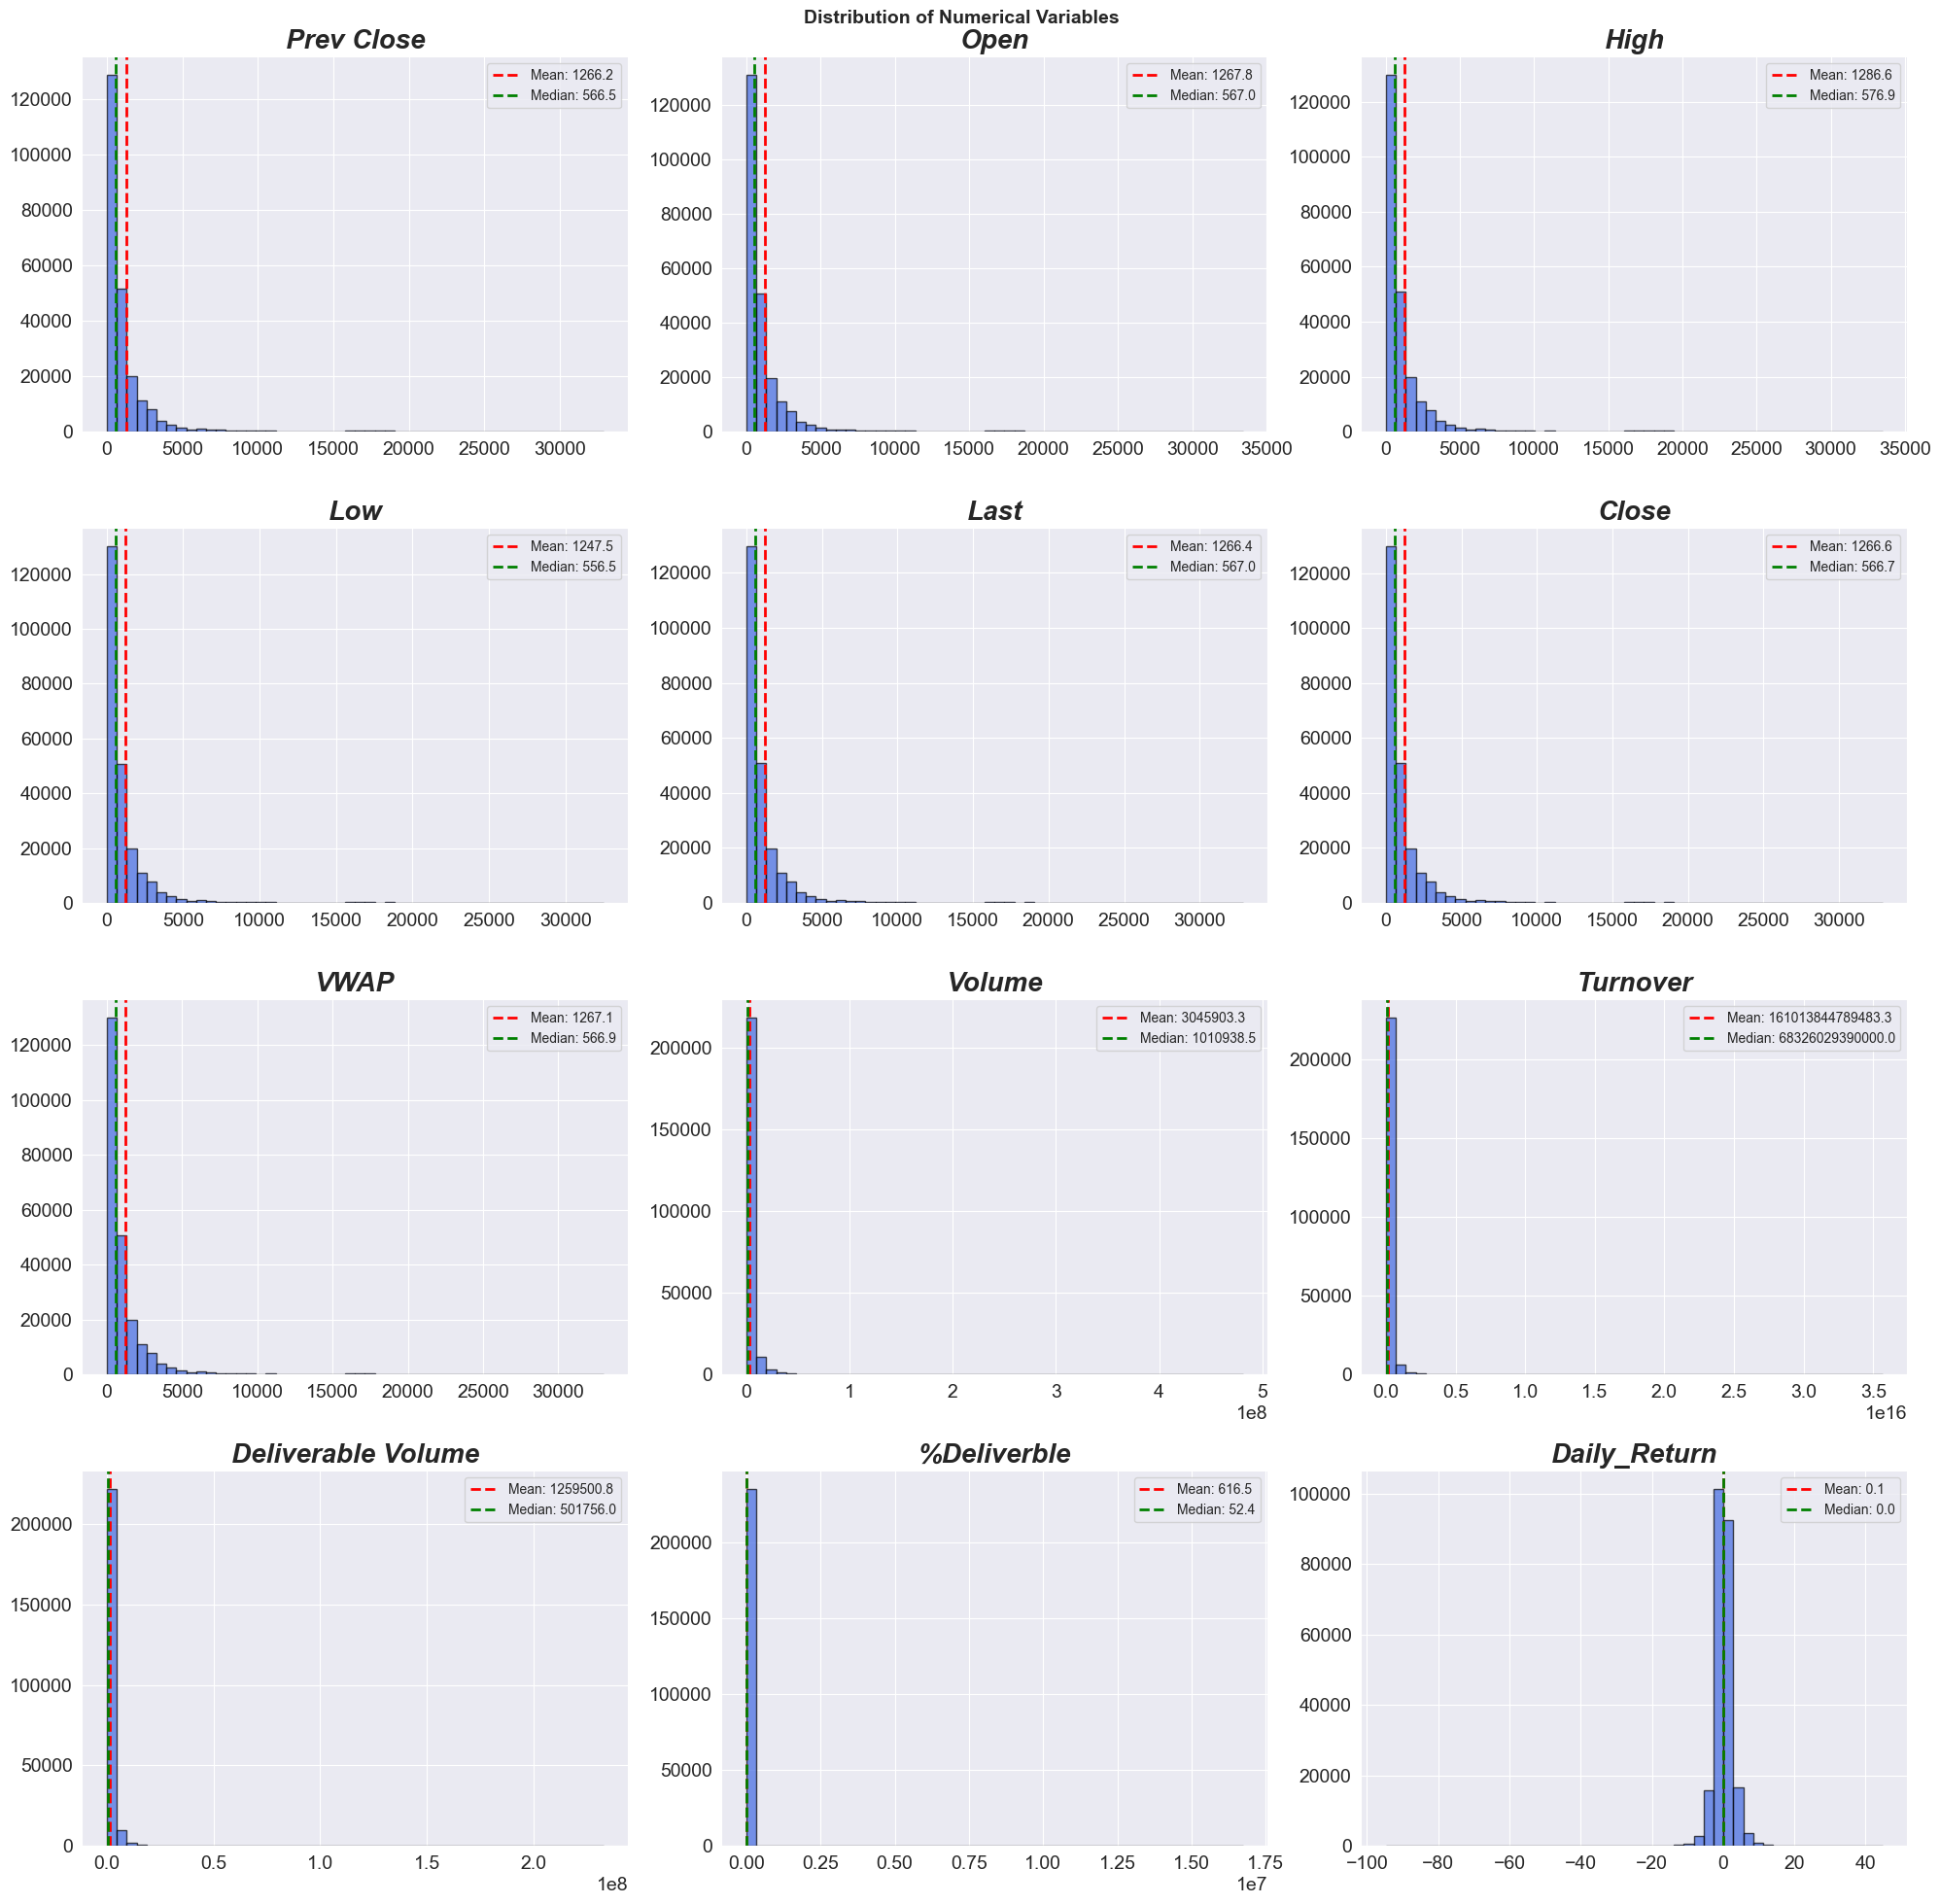

In [44]:
fig,axes = plt.subplots(4,3,figsize=(20,20))
axes = axes.flatten() # coverts from 2d -> 1d

for index,col in enumerate(numerical_columns):
    axes[index].hist(data_copy[col],bins=50,color='royalblue',edgecolor='black',alpha=0.7)
    axes[index].axvline(data_copy[col].mean(),color='red',linestyle='dashed',linewidth=2,label=f"Mean: {data_copy[col].mean():.1f}")
    axes[index].axvline(data_copy[col].median(),label=f"Median: {data_copy[col].median():.1f}",color='green',linestyle='dashed',linewidth=2)
    axes[index].set_title(col,fontsize=20,fontdict={'fontweight':'bold','fontstyle':'oblique'})
    axes[index].legend(fontsize=10)

for j in range(len(numerical_columns),len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Univariante analysis of the categorical variables
Date and Series we are not examining as they are not important.

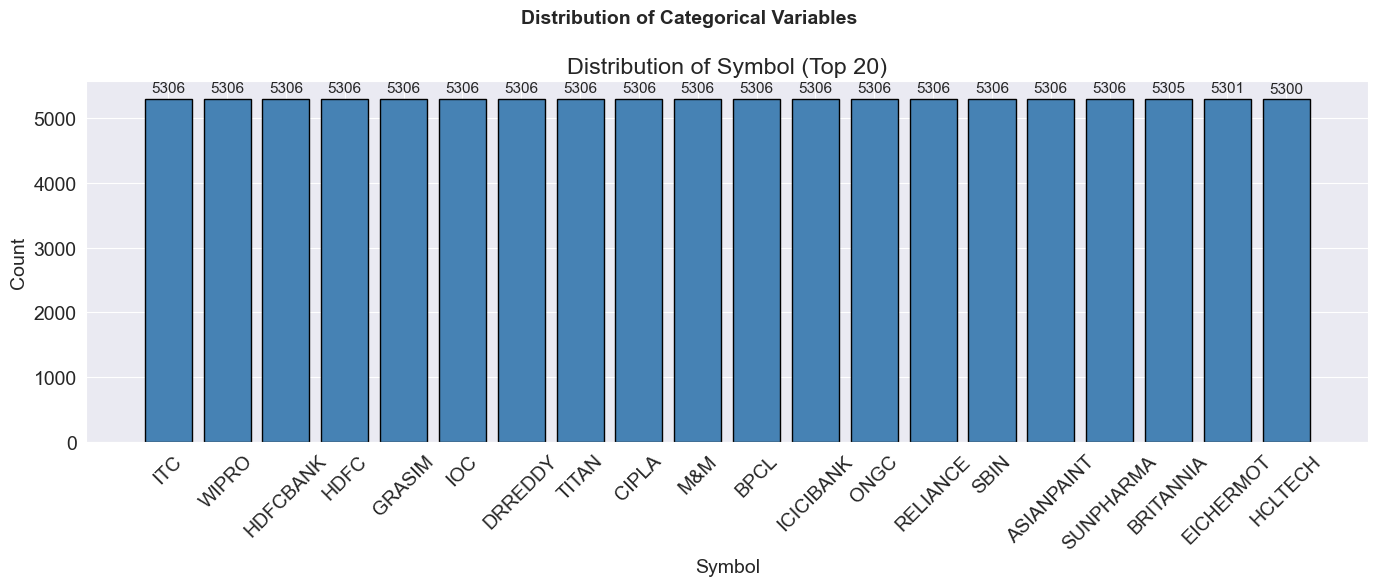

Total unique stocks: 65
Top 20 stocks represent 106108 out of 235192 total records (45.1%)

Top 10 stocks by frequency:
ITC: 5306 records (2.26%)
WIPRO: 5306 records (2.26%)
HDFCBANK: 5306 records (2.26%)
HDFC: 5306 records (2.26%)
GRASIM: 5306 records (2.26%)
IOC: 5306 records (2.26%)
DRREDDY: 5306 records (2.26%)
TITAN: 5306 records (2.26%)
CIPLA: 5306 records (2.26%)
M&M: 5306 records (2.26%)
Total unique stocks: 65
Top 20 stocks represent 106108 out of 235192 total records (45.1%)

Top 10 stocks by frequency:
ITC: 5306 records (2.26%)
WIPRO: 5306 records (2.26%)
HDFCBANK: 5306 records (2.26%)
HDFC: 5306 records (2.26%)
GRASIM: 5306 records (2.26%)
IOC: 5306 records (2.26%)
DRREDDY: 5306 records (2.26%)
TITAN: 5306 records (2.26%)
CIPLA: 5306 records (2.26%)
M&M: 5306 records (2.26%)


In [45]:
categorical_columns = ['Symbol']

col = categorical_columns[0]

fig, axes = plt.subplots(figsize=(14,6))

counts = data_copy[col].value_counts().head(20)

bars = axes.bar(
    counts.index.astype(str),
    counts.values,
    color='steelblue',
    edgecolor='black'
)

axes.set_title(f"Distribution of {col} (Top 20)")
axes.set_xlabel(col)
axes.set_ylabel('Count')
axes.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, counts.values):
    axes.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        str(val),
        ha='center',
        fontsize=11
    )

plt.suptitle('Distribution of Categorical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Add percentages and summary statistics
total_stocks = data_copy['Symbol'].nunique()
print(f"Total unique stocks: {total_stocks}")
print(f"Top 20 stocks represent {counts.sum()} out of {len(data_copy)} total records ({counts.sum()/len(data_copy)*100:.1f}%)")
print("\nTop 10 stocks by frequency:")
top_10 = data_copy['Symbol'].value_counts().head(10)
for stock, count in top_10.items():
    pct = count / len(data_copy) * 100
    print(f"{stock}: {count} records ({pct:.2f}%)")

# Add percentages and summary statistics
total_stocks = data_copy['Symbol'].nunique()
print(f"Total unique stocks: {total_stocks}")
print(f"Top 20 stocks represent {counts.sum()} out of {len(data_copy)} total records ({counts.sum()/len(data_copy)*100:.1f}%)")
print("\nTop 10 stocks by frequency:")
top_10 = data_copy['Symbol'].value_counts().head(10)
for stock, count in top_10.items():
    pct = count / len(data_copy) * 100
    print(f"{stock}: {count} records ({pct:.2f}%)")

### Bivariant Analysis

2a. Volume vs Return (Number vs Number)

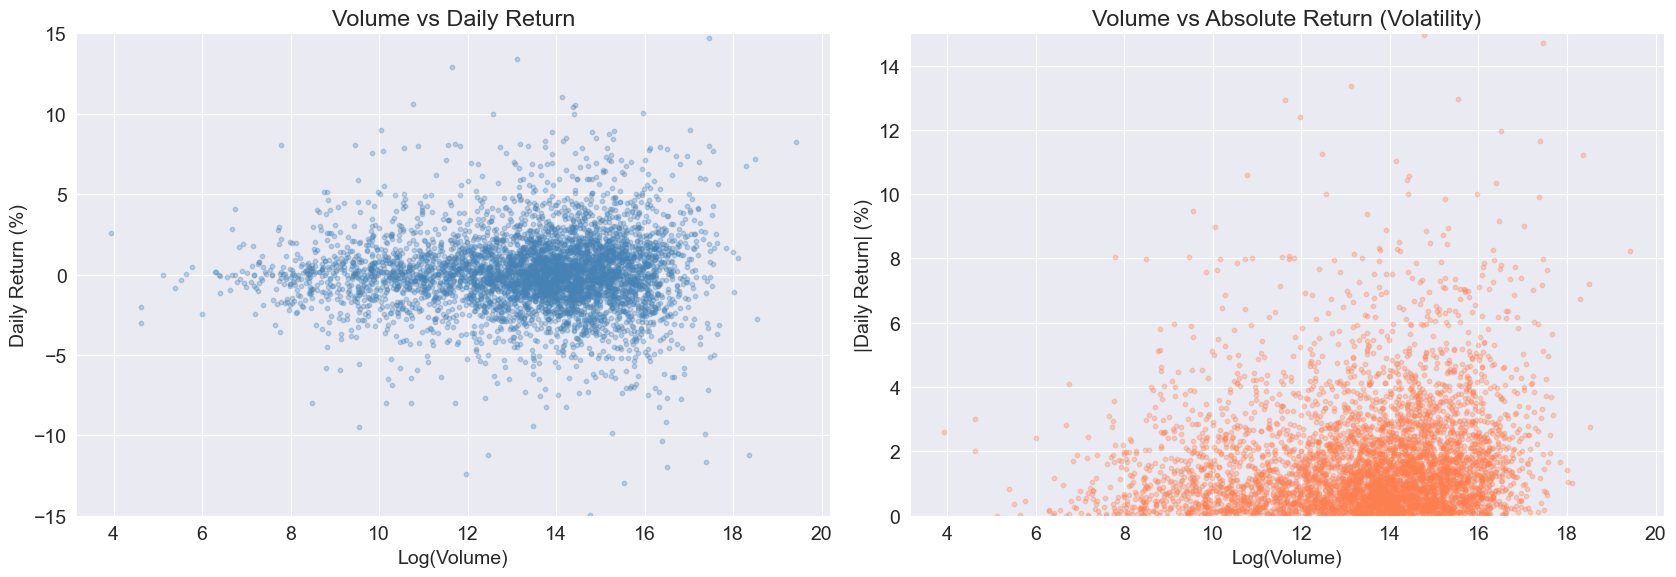

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sample = data_copy.dropna(subset=['Daily_Return']).sample(5000, random_state=42)  # sample for speed

# Scatter plot
axes[0].scatter(np.log1p(sample['Volume']), sample['Daily_Return'], 
                alpha=0.3, color='steelblue', s=10)
axes[0].set_xlabel('Log(Volume)')
axes[0].set_ylabel('Daily Return (%)')
axes[0].set_title('Volume vs Daily Return')
axes[0].set_ylim(-15, 15)

# Absolute return vs volume (does high volume = big moves?)
sample['Abs_Return'] = sample['Daily_Return'].abs()
axes[1].scatter(np.log1p(sample['Volume']), sample['Abs_Return'], 
                alpha=0.3, color='coral', s=10)
axes[1].set_xlabel('Log(Volume)')
axes[1].set_ylabel('|Daily Return| (%)')
axes[1].set_title('Volume vs Absolute Return (Volatility)')
axes[1].set_ylim(0, 15)

plt.tight_layout()
plt.show()

### 2b. Intraday Range vs Return (High-Low spread)

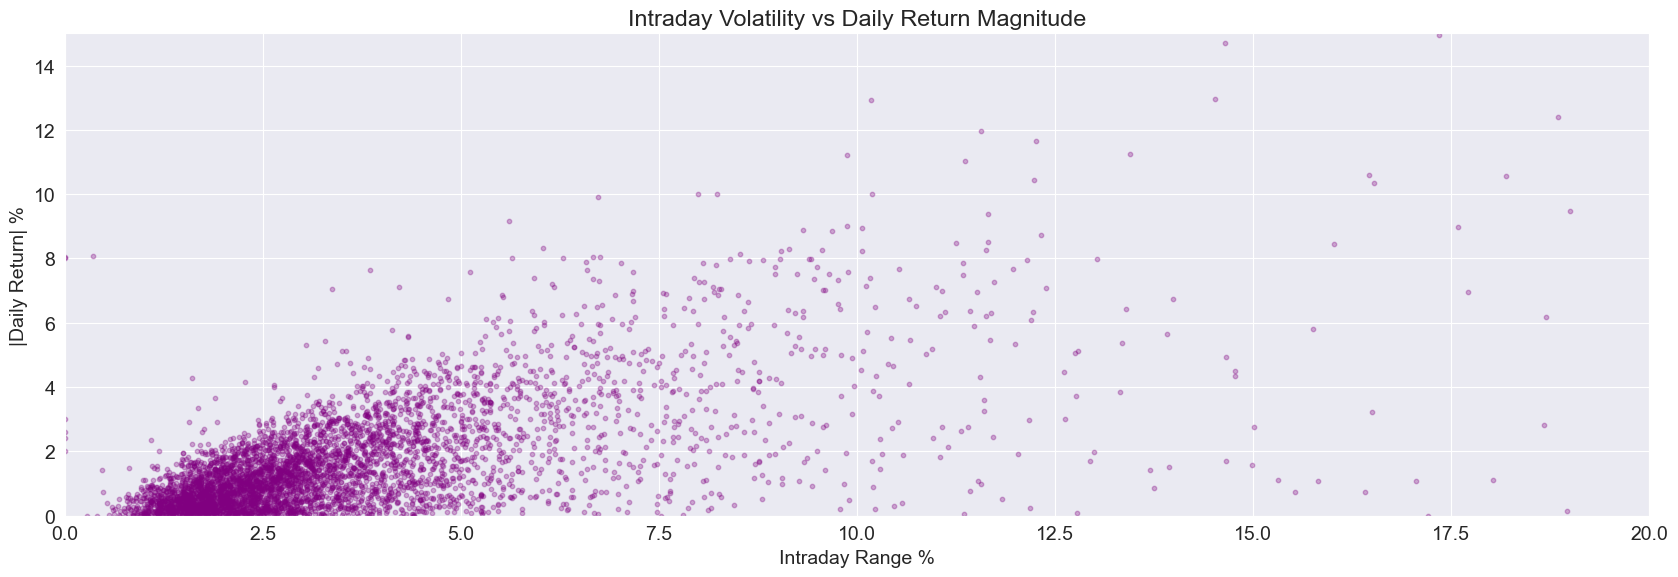

In [47]:
# Intraday range = how much did the stock move within the day
data_copy['Intraday_Range'] = ((data_copy['High'] - data_copy['Low']) / data_copy['Low']) * 100

fig, ax = plt.subplots(figsize=(17, 6))
sample = data_copy.dropna(subset=['Daily_Return']).sample(5000, random_state=42)

ax.scatter(sample['Intraday_Range'], sample['Daily_Return'].abs(), 
           alpha=0.3, color='purple', s=10)
ax.set_xlabel('Intraday Range %')
ax.set_ylabel('|Daily Return| %')
ax.set_title('Intraday Volatility vs Daily Return Magnitude')
ax.set_xlim(0, 20)
ax.set_ylim(0, 15)

plt.tight_layout()
plt.show()

### 2c. Deliverable Volume % vs Return (Category-like vs Number)

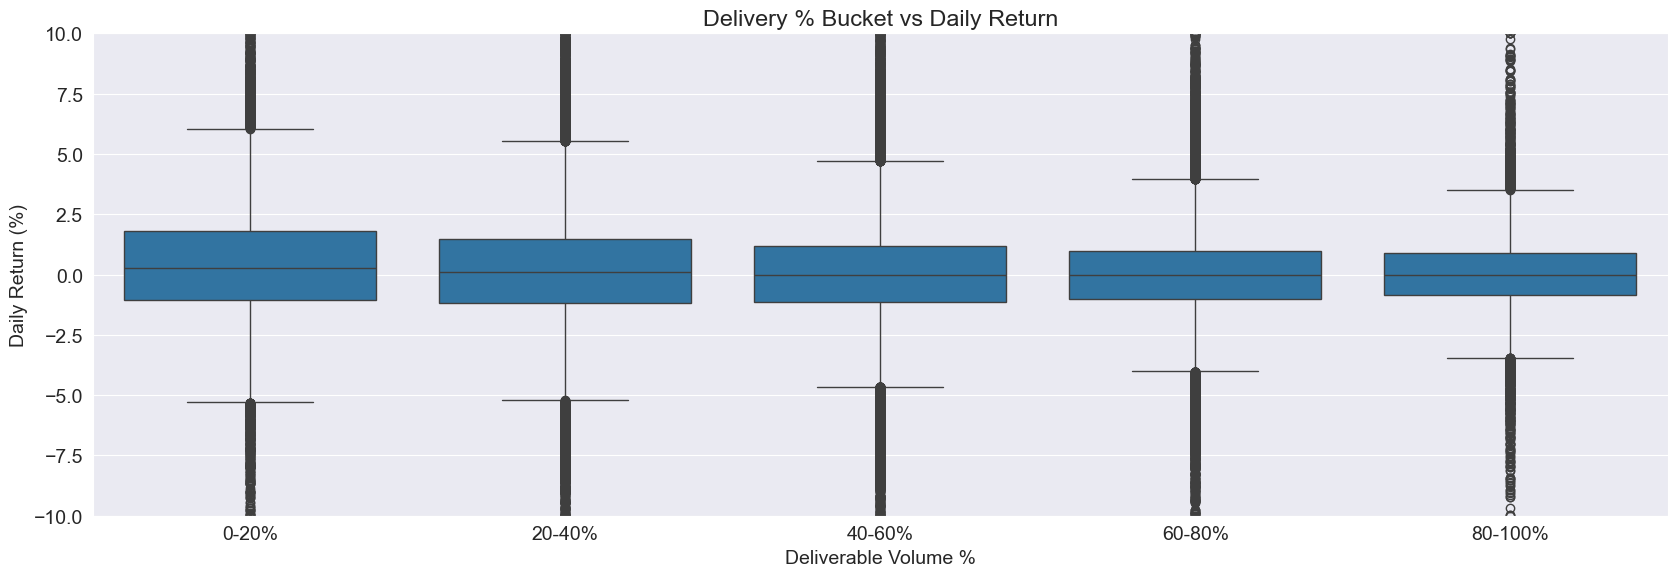

In [48]:
# High deliverable % = more people are actually buying to hold (not just trading)
# Low deliverable % = mostly intraday/speculative trading

# Create buckets (note: %Deliverble is stored as a percentage from 0 to 100)
data_copy['Delivery_Bucket'] = pd.cut(data_copy['%Deliverble'], 
                                       bins=[0, 20, 40, 60, 80, 100],
                                       labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])

fig, ax = plt.subplots(figsize=(17, 6))
delivery_returns = data_copy.dropna(subset=['Daily_Return', 'Delivery_Bucket'])

sns.boxplot(x='Delivery_Bucket', y='Daily_Return', data=delivery_returns, ax=ax)
ax.set_title('Delivery % Bucket vs Daily Return')
ax.set_xlabel('Deliverable Volume %')
ax.set_ylabel('Daily Return (%)')
ax.set_ylim(-10, 10)

plt.tight_layout()
plt.show()


### 2d. Stock-wise Return Distribution (Category vs Number)

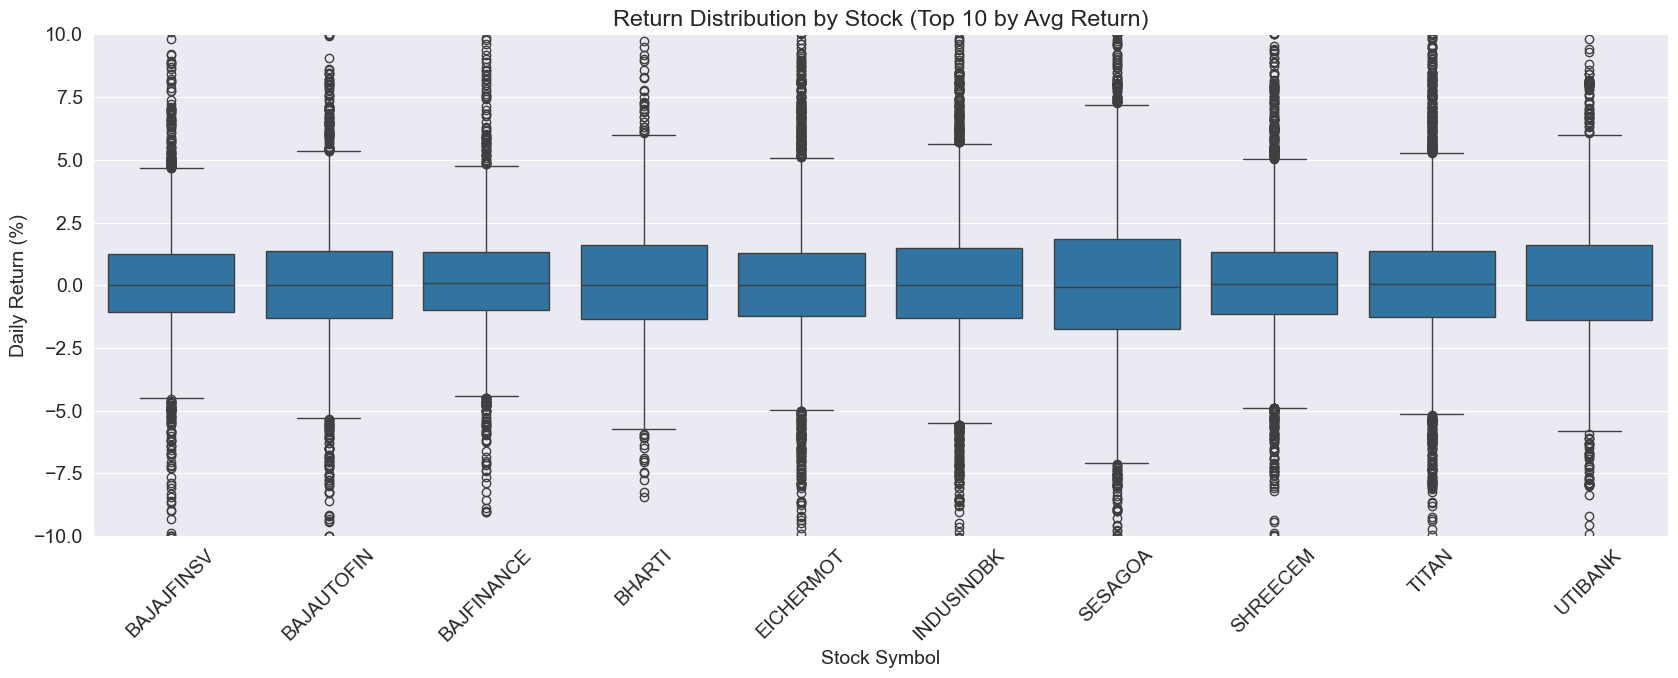

In [49]:
# Top 10 stocks by average return
top_stocks = data_copy.groupby('Symbol')['Daily_Return'].mean().nlargest(10).index

fig, ax = plt.subplots(figsize=(17, 7))
filtered = data_copy[data_copy['Symbol'].isin(top_stocks)].dropna(subset=['Daily_Return'])

sns.boxplot(x='Symbol', y='Daily_Return', data=filtered, ax=ax)
ax.set_title('Return Distribution by Stock (Top 10 by Avg Return)')
ax.set_xlabel('Stock Symbol')
ax.set_ylabel('Daily Return (%)')
ax.set_ylim(-10, 10)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 2e. Numerical Variables vs Delivery Bucket

Similar to how we analyzed numerical variables against churn in banking data, here we examine how numerical stock features vary across delivery buckets. This helps understand the characteristics of different trading patterns.

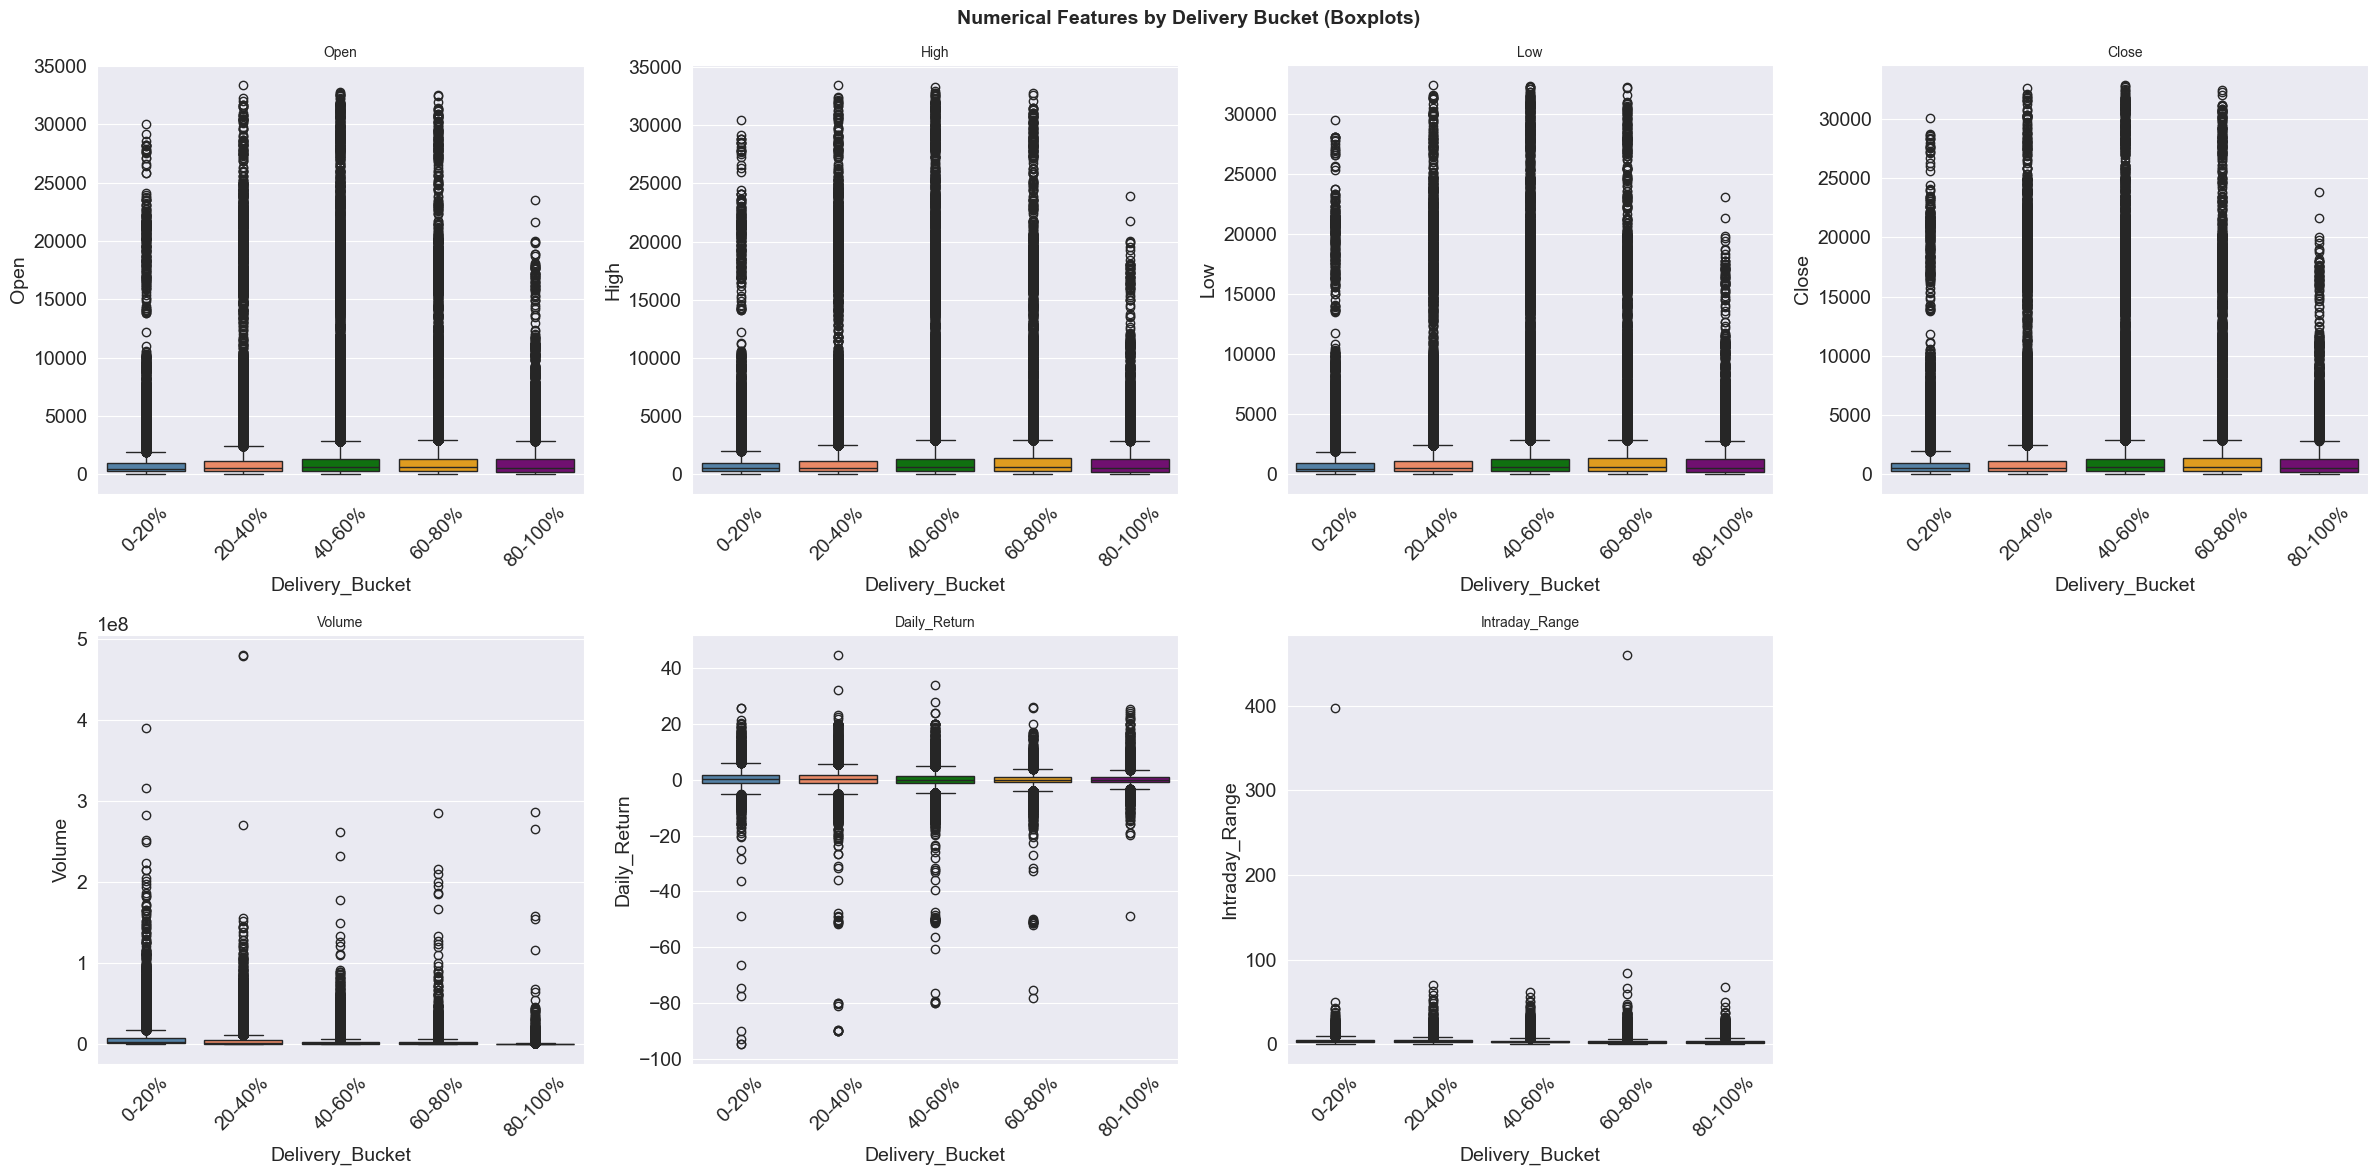

In [50]:
# Select key numerical variables for analysis
key_numerical = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Intraday_Range']

# Boxplots for numerical variables by Delivery Bucket
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, col in enumerate(key_numerical):
    sns.boxplot(data=data_copy, x='Delivery_Bucket', y=col, ax=axes[i],
                palette=['steelblue', 'coral', 'green', 'orange', 'purple'])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticklabels(['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(key_numerical), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features by Delivery Bucket (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

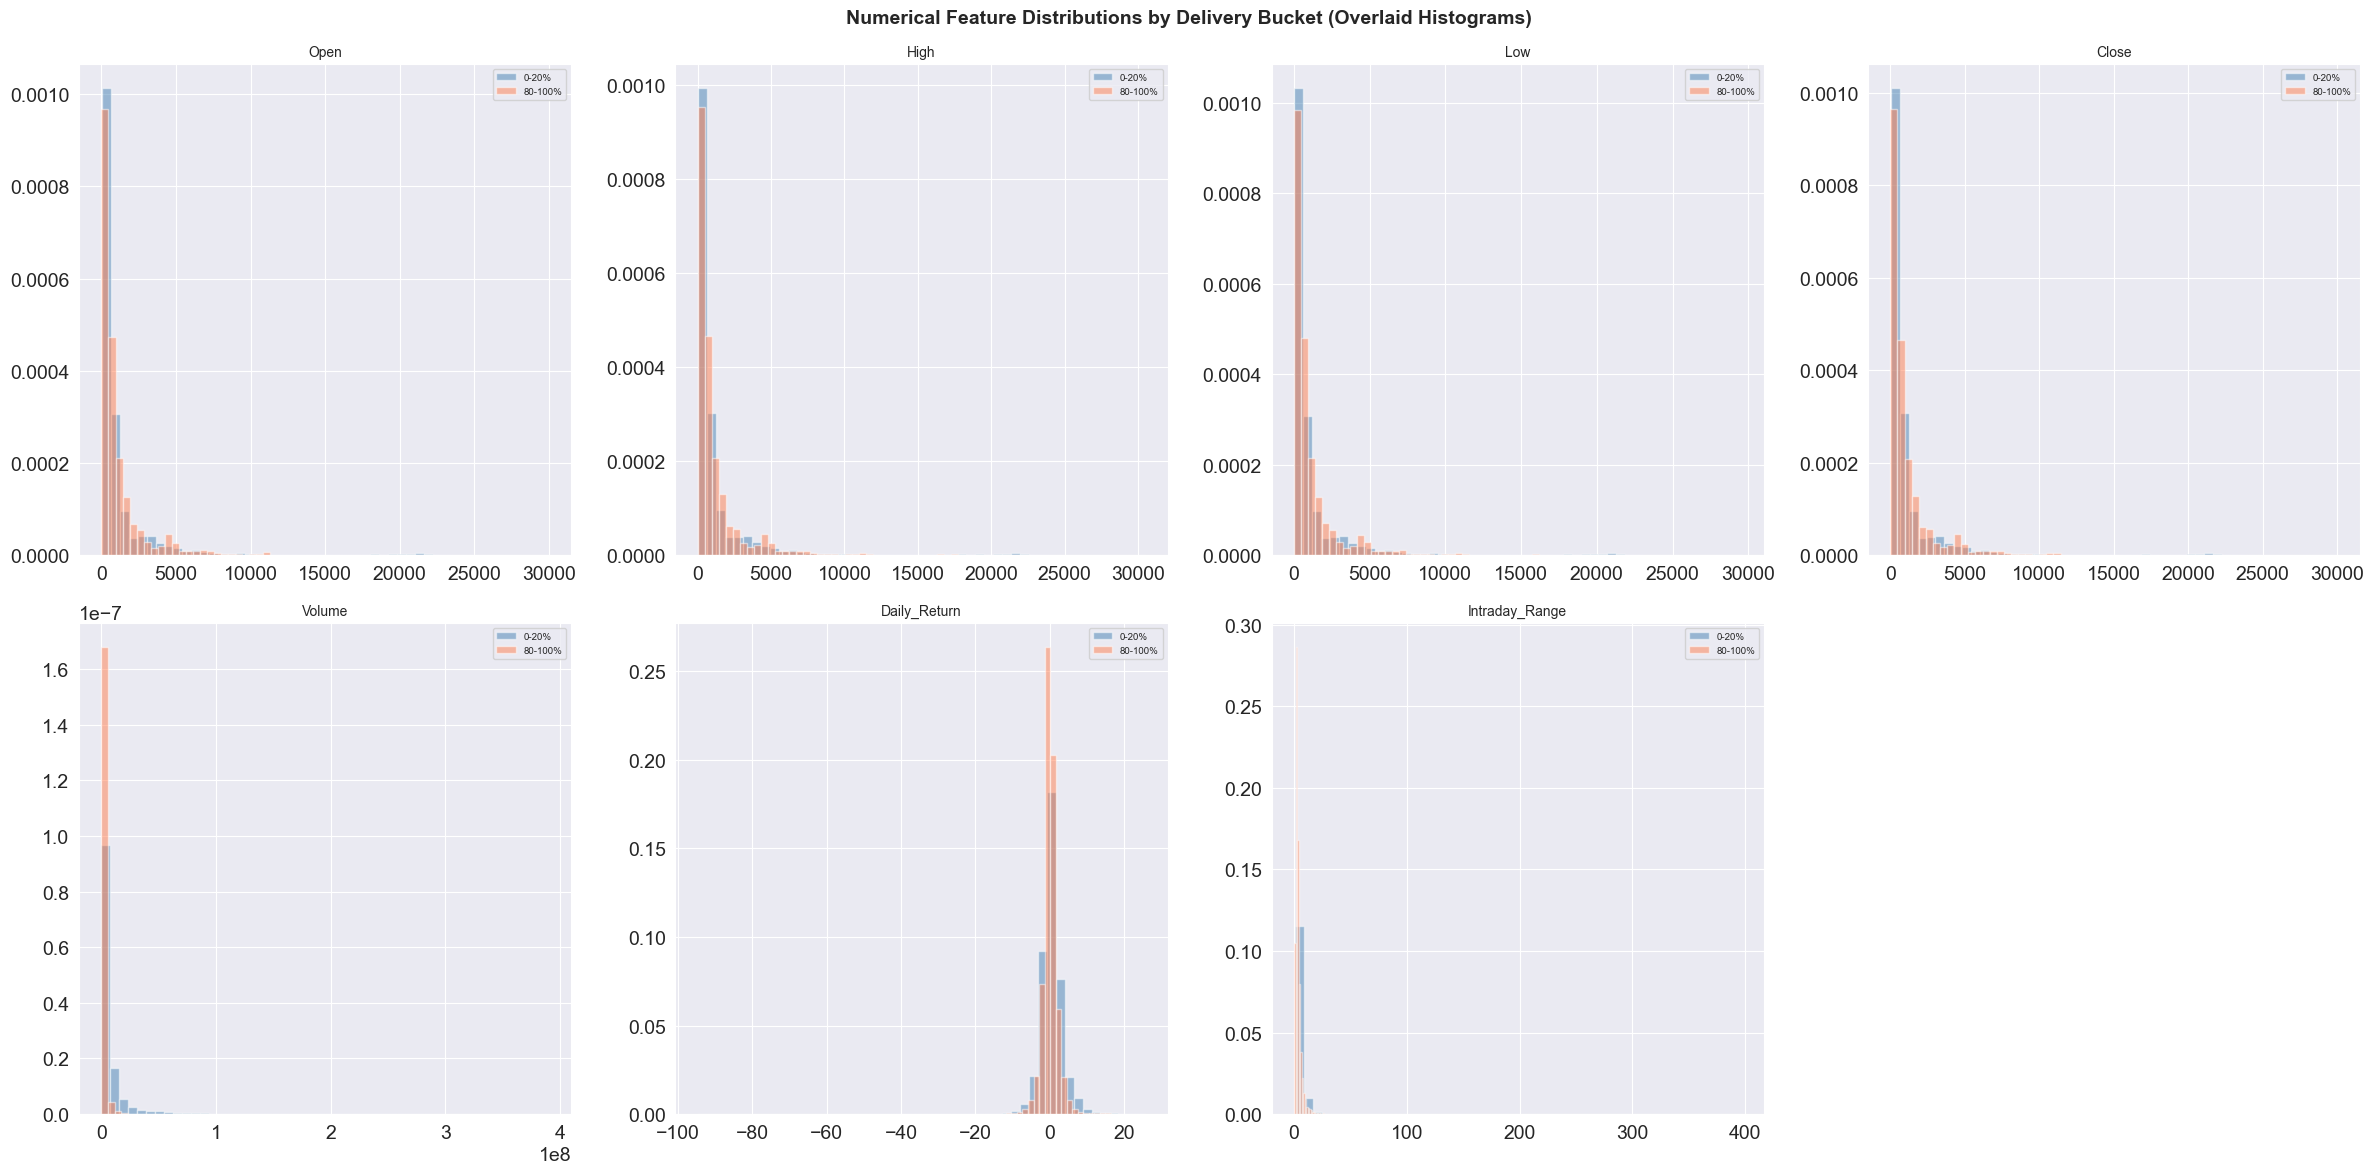

In [51]:
# Overlaid histograms for key variables by Delivery Bucket
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, col in enumerate(key_numerical):
    for bucket, color, label in [('0-20%', 'steelblue', '0-20%'),
                                 ('80-100%', 'coral', '80-100%')]:
        subset = data_copy[data_copy['Delivery_Bucket'] == bucket][col].dropna()
        axes[i].hist(subset, bins=50, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

for j in range(len(key_numerical), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Delivery Bucket (Overlaid Histograms)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
# Crosstab analysis for Delivery Bucket
print("Delivery Bucket Distribution:")
delivery_counts = data_copy['Delivery_Bucket'].value_counts().sort_index()
delivery_pct = data_copy['Delivery_Bucket'].value_counts(normalize=True).sort_index() * 100

delivery_summary = pd.DataFrame({
    'Count': delivery_counts,
    'Percentage': delivery_pct.round(2)
})
print(delivery_summary)

print(f"\nTotal records: {len(data_copy)}")
print(f"Most common delivery bucket: {delivery_counts.idxmax()} ({delivery_pct.max():.1f}%)")
print(f"Least common delivery bucket: {delivery_counts.idxmin()} ({delivery_pct.min():.1f}%)")

# Average returns by delivery bucket
print("\nAverage Daily Return by Delivery Bucket:")
returns_by_bucket = data_copy.groupby('Delivery_Bucket')['Daily_Return'].mean() * 100
print(returns_by_bucket.round(4).to_string())

Delivery Bucket Distribution:
                 Count  Percentage
Delivery_Bucket                   
0-20%            15251        6.84
20-40%           53131       23.83
40-60%           82942       37.20
60-80%           58925       26.43
80-100%          12719        5.70

Total records: 235192
Most common delivery bucket: 40-60% (37.2%)
Least common delivery bucket: 80-100% (5.7%)

Average Daily Return by Delivery Bucket:
Delivery_Bucket
0-20%      41.0176
20-40%     17.8000
40-60%      3.2555
60-80%     -2.8925
80-100%     8.0819


### Step 3: Correlation Analysis

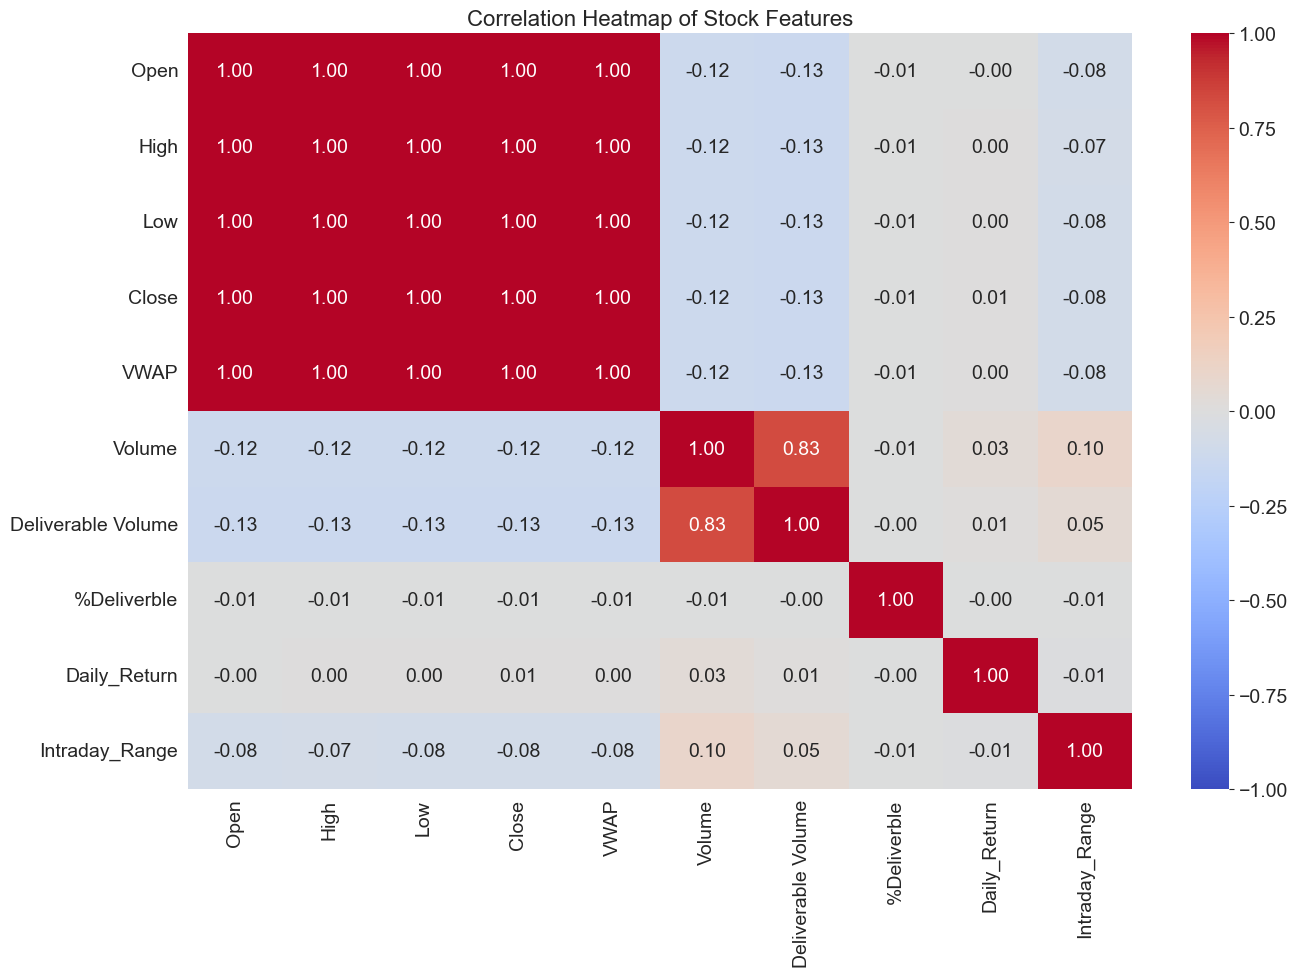

In [53]:
# Select relevant columns
cols_for_corr = ['Open', 'High', 'Low', 'Close', 'VWAP', 'Volume', 
                 'Deliverable Volume', '%Deliverble', 'Daily_Return', 'Intraday_Range']

corr_matrix = data_copy[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            ax=ax)
ax.set_title('Correlation Heatmap of Stock Features', fontsize=16)
plt.tight_layout()
plt.show()


### How to read this:

- Values close to +1 (dark red) = strong positive relationship
- Values close to -1 (dark blue) = strong negative relationship
- Values close to 0 (white) = no relationship

### Step 4: Hypothesis Testing

In EDA for stock data, hypothesis testing helps us check whether the differences we see are likely real or just random noise. We will compare returns for:

- low vs high delivery percentage days
- low vs high volume days

Even if the average differences are small, a very low p-value tells us the pattern is statistically significant.

In [54]:
from scipy.stats import ttest_ind

# Compare the two delivery buckets
low_delivery = data_copy[data_copy['Delivery_Bucket'] == '0-20%']['Daily_Return'].dropna()
high_delivery = data_copy[data_copy['Delivery_Bucket'] == '80-100%']['Daily_Return'].dropna()

# Compare low and high volume days
volume_q_low = data_copy['Volume'].quantile(0.2)
volume_q_high = data_copy['Volume'].quantile(0.8)
low_volume = data_copy[data_copy['Volume'] <= volume_q_low]['Daily_Return'].dropna()
high_volume = data_copy[data_copy['Volume'] >= volume_q_high]['Daily_Return'].dropna()

print('Low delivery count:', len(low_delivery), 'High delivery count:', len(high_delivery))
print('Low delivery mean return: {:.4f}%'.format(low_delivery.mean()))
print('High delivery mean return: {:.4f}%'.format(high_delivery.mean()))

delivery_tstat, delivery_p = ttest_ind(low_delivery, high_delivery, equal_var=False)
print('Delivery bucket t-statistic:', delivery_tstat)
print('Delivery bucket p-value:', delivery_p)

print('\nLow volume count:', len(low_volume), 'High volume count:', len(high_volume))
print('Low volume mean return: {:.4f}%'.format(low_volume.mean()))
print('High volume mean return: {:.4f}%'.format(high_volume.mean()))

volume_tstat, volume_p = ttest_ind(low_volume, high_volume, equal_var=False)
print('Volume bucket t-statistic:', volume_tstat)
print('Volume bucket p-value:', volume_p)

Low delivery count: 15245 High delivery count: 12718
Low delivery mean return: 0.4102%
High delivery mean return: 0.0808%
Delivery bucket t-statistic: 9.354739119191358
Delivery bucket p-value: 9.023680451158692e-21

Low volume count: 47009 High volume count: 47025
Low volume mean return: -0.0220%
High volume mean return: 0.1529%
Volume bucket t-statistic: -9.199342261979579
Volume bucket p-value: 3.679586311162043e-20


### Summary of Findings

- Price-based features (`Open`, `High`, `Low`, `Close`, `VWAP`) are highly correlated because they all describe the same stock movement for a given day.
- `Daily_Return` is not strongly correlated with raw `Volume`, which means volume alone is not a reliable predictor of whether the stock will go up or down.
- `Intraday_Range` is strongly related to the magnitude of the return, showing that larger intraday swings usually appear on days with larger price changes.
- The `Delivery %` bucket analysis suggests that the type of trading activity has a measurable but modest relationship with average daily returns.
- Hypothesis tests show that the return differences between the extreme buckets are statistically significant, even though the differences in mean returns are small.

This EDA is useful because it helps you separate strong structural relationships from weak or noisy ones, and it tells you which features are worth further modeling.

### Step 5: Time Series Analysis

Since stock data is inherently time-dependent, we should examine trends, seasonality, and autocorrelation. This helps understand if returns have patterns over time or are purely random.

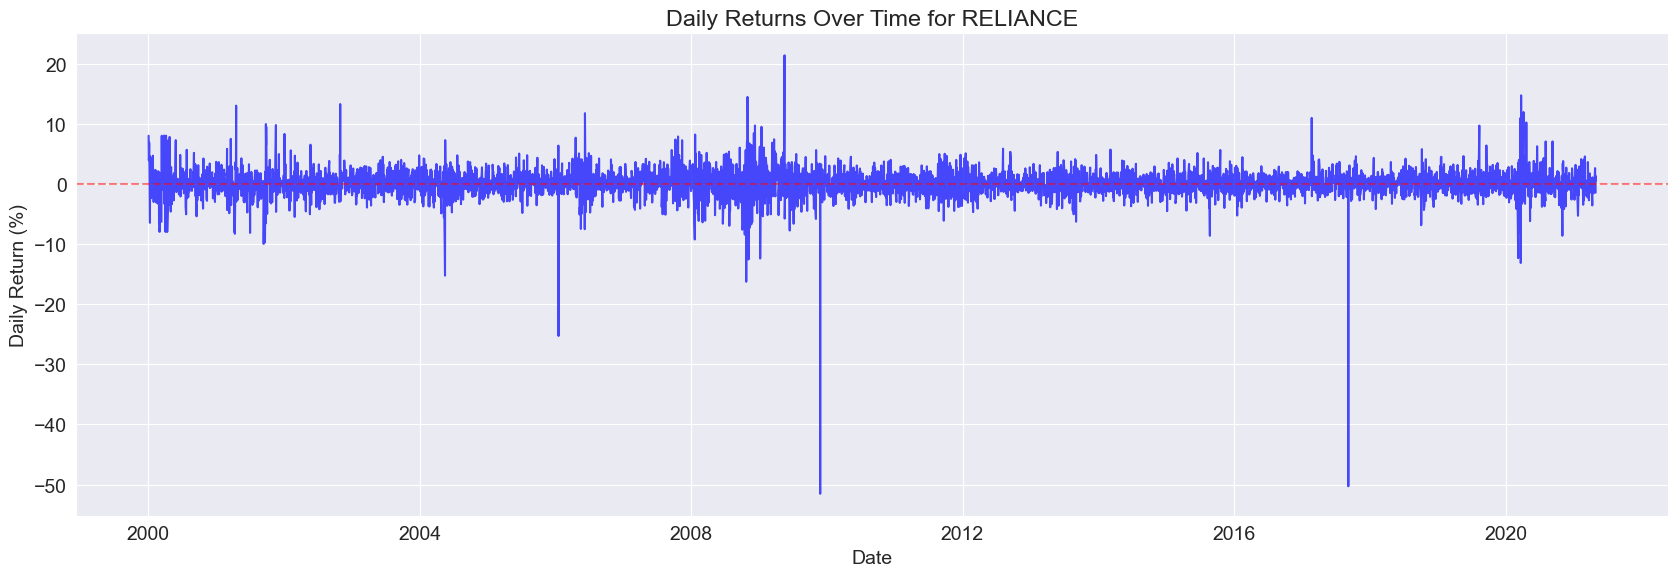

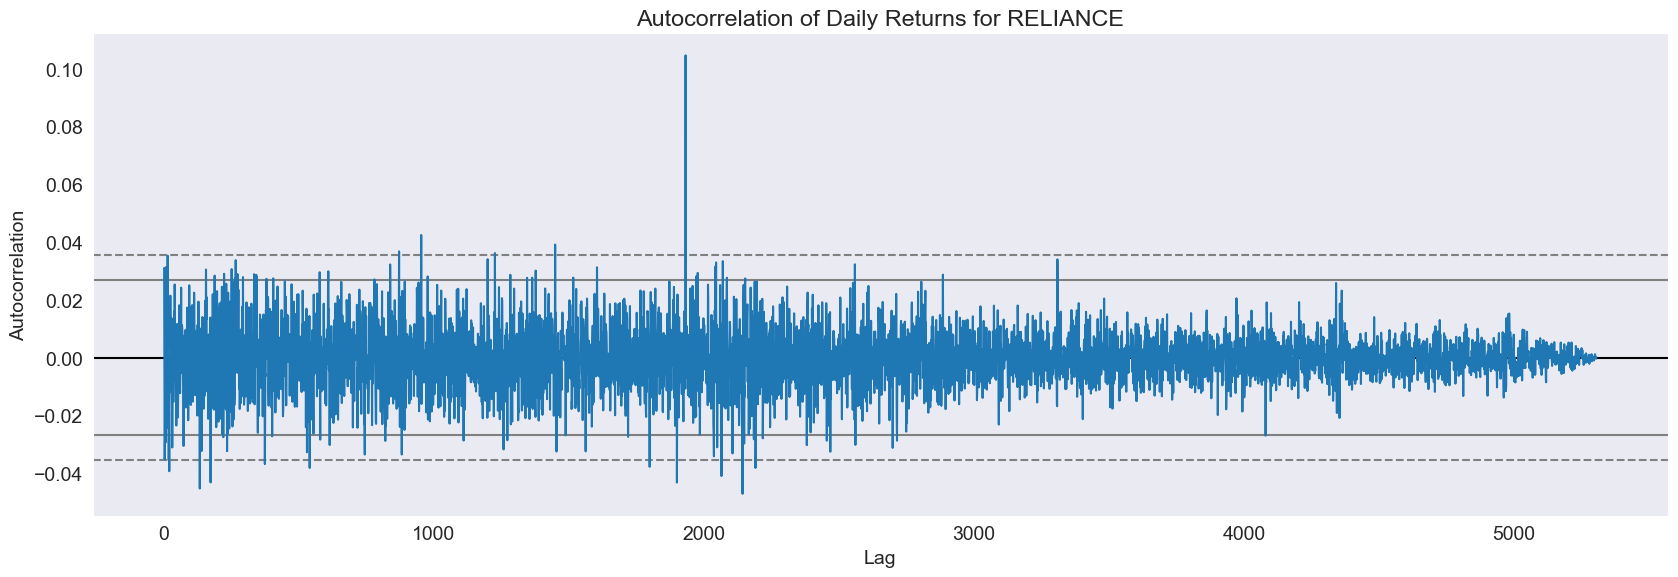

In [55]:
# Plot daily returns over time for a sample stock (e.g., RELIANCE)
sample_stock = 'RELIANCE'
stock_data = data_copy[data_copy['Symbol'] == sample_stock].copy()
stock_data = stock_data.set_index('Date')

fig, ax = plt.subplots(figsize=(17, 6))
ax.plot(stock_data.index, stock_data['Daily_Return'], alpha=0.7, color='blue')
ax.set_title(f'Daily Returns Over Time for {sample_stock}')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Return (%)')
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Autocorrelation plot to check if returns are correlated with past values
from pandas.plotting import autocorrelation_plot
fig, ax = plt.subplots(figsize=(17, 6))
autocorrelation_plot(stock_data['Daily_Return'].dropna(), ax=ax)
ax.set_title(f'Autocorrelation of Daily Returns for {sample_stock}')
plt.tight_layout()
plt.show()

### Step 6: Outlier Detection

Outliers can skew analysis. We'll use IQR method to identify extreme returns.

Number of outliers in Daily_Return: 13930
Outlier bounds: Lower = -4.61%, Upper = 4.72%


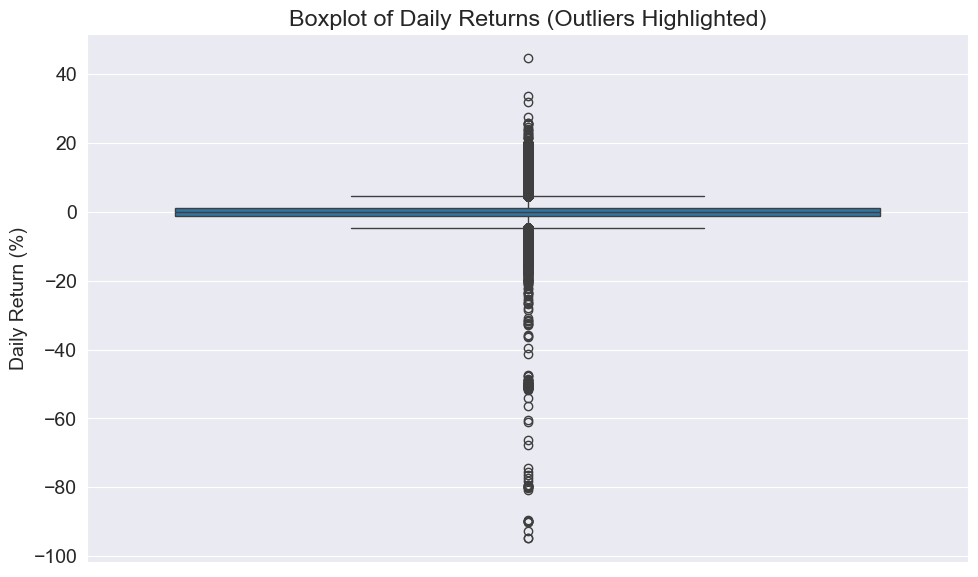

In [56]:
# Outlier detection using IQR for Daily_Return
Q1 = data_copy['Daily_Return'].quantile(0.25)
Q3 = data_copy['Daily_Return'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data_copy[(data_copy['Daily_Return'] < lower_bound) | (data_copy['Daily_Return'] > upper_bound)]
print(f"Number of outliers in Daily_Return: {len(outliers)}")
print(f"Outlier bounds: Lower = {lower_bound:.2f}%, Upper = {upper_bound:.2f}%")

# Plot boxplot to visualize outliers
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(y=data_copy['Daily_Return'], ax=ax)
ax.set_title('Boxplot of Daily Returns (Outliers Highlighted)')
ax.set_ylabel('Daily Return (%)')
plt.tight_layout()
plt.show()

### Step 7: Multivariate Analysis - Pair Plot

To see relationships between multiple variables at once.

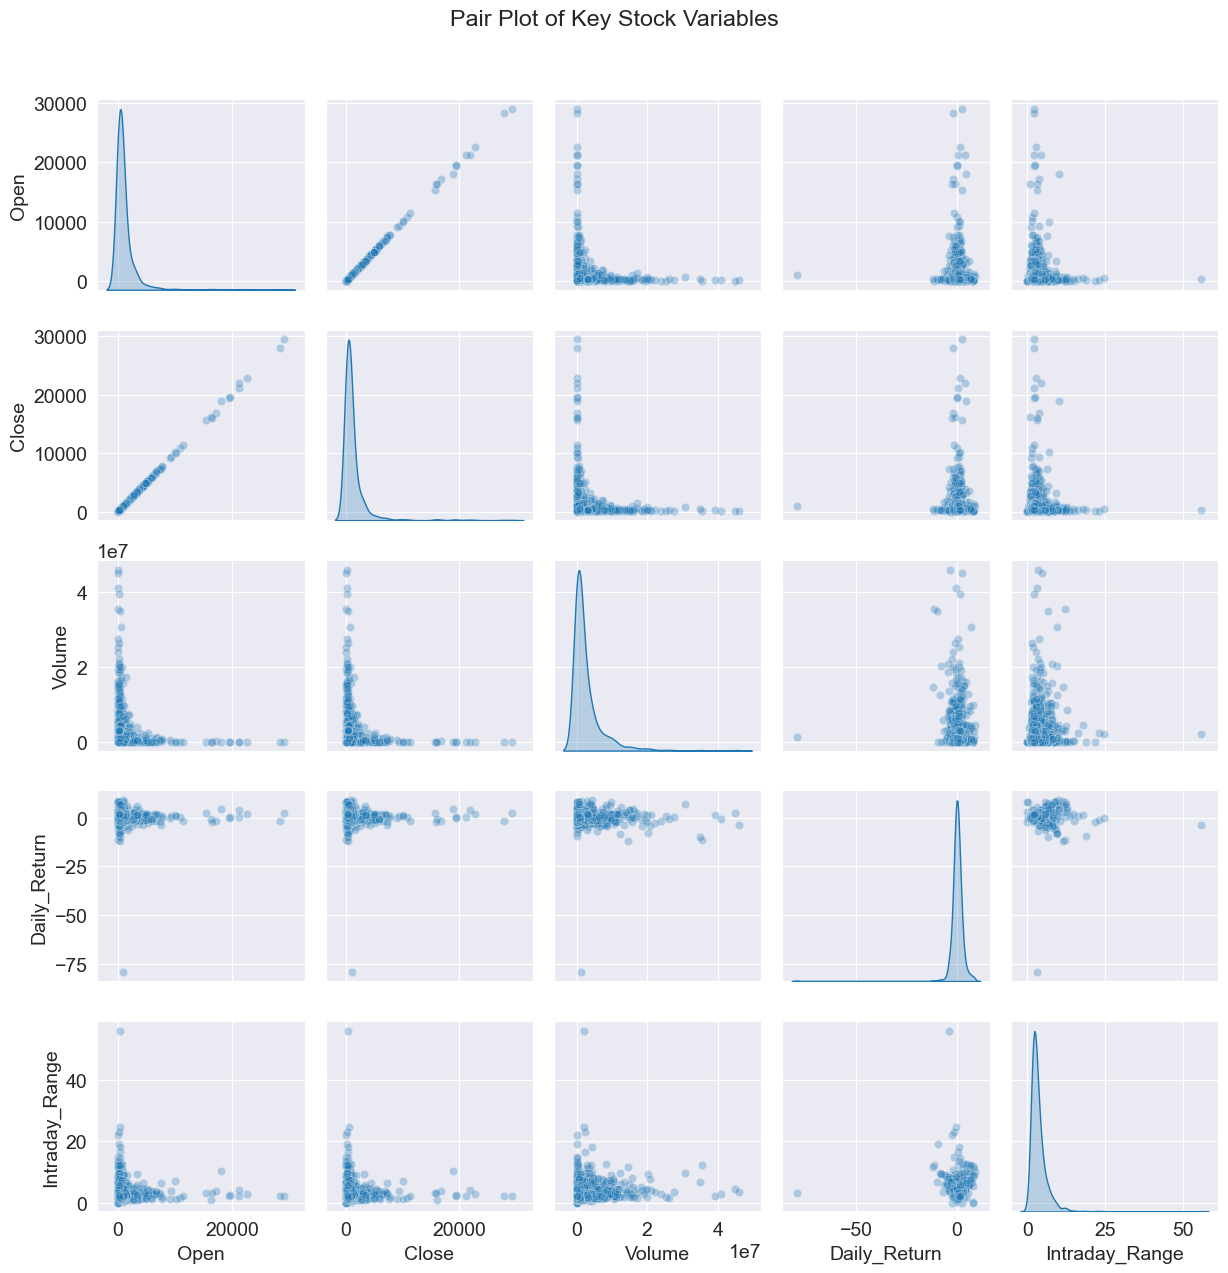

In [57]:
# Pair plot for key numerical variables (sample for speed)
pair_vars = ['Open', 'Close', 'Volume', 'Daily_Return', 'Intraday_Range']
sample_data = data_copy[pair_vars].dropna().sample(1000, random_state=42)

sns.pairplot(sample_data, diag_kind='kde', plot_kws={'alpha': 0.3})
plt.suptitle('Pair Plot of Key Stock Variables', y=1.02)
plt.tight_layout()
plt.show()

### Step 8: Normality and Distribution Tests

Check if returns follow normal distribution (important for many statistical models).

Shapiro-Wilk Test: Statistic=0.7796, p-value=0.0000
Daily returns do not appear normally distributed (reject H0)
D'Agostino Test: Statistic=6180.9233, p-value=0.0000


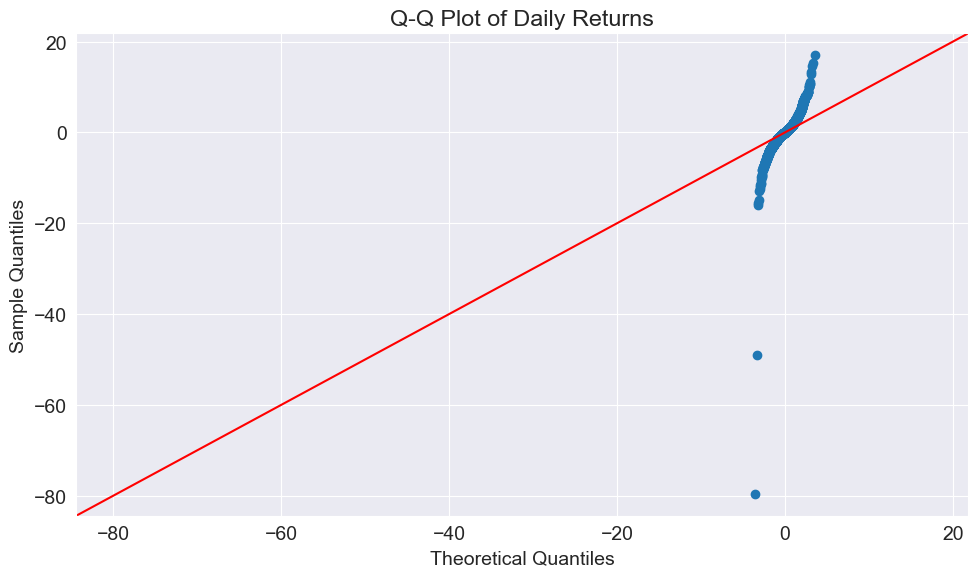

In [58]:
from scipy.stats import shapiro, normaltest

# Test normality of daily returns (sample for speed)
returns_sample = data_copy['Daily_Return'].dropna().sample(5000, random_state=42)

# Shapiro-Wilk test
stat, p = shapiro(returns_sample)
print(f'Shapiro-Wilk Test: Statistic={stat:.4f}, p-value={p:.4f}')
if p > 0.05:
    print('Daily returns appear normally distributed (fail to reject H0)')
else:
    print('Daily returns do not appear normally distributed (reject H0)')

# D'Agostino and Pearson's test
stat, p = normaltest(returns_sample)
print(f'D\'Agostino Test: Statistic={stat:.4f}, p-value={p:.4f}')

# Q-Q plot
import statsmodels.api as sm
fig, ax = plt.subplots(figsize=(10, 6))
sm.qqplot(returns_sample, line='45', ax=ax)
ax.set_title('Q-Q Plot of Daily Returns')
plt.tight_layout()
plt.show()

### Step 9: Feature Engineering Suggestions

Based on EDA, here are some features you could create for modeling:

1. **Moving Averages**: 5-day, 20-day MA of Close price
2. **Volatility Measures**: Rolling standard deviation of returns
3. **Momentum Indicators**: RSI, MACD
4. **Volume Ratios**: Volume / Average Volume
5. **Price Changes**: % change from Prev Close

Example implementation:

In [59]:
# Feature Engineering Examples
# Sort data for rolling calculations
data_copy = data_copy.sort_values(['Symbol', 'Date'])

# Moving averages
data_copy['MA_5'] = data_copy.groupby('Symbol')['Close'].transform(lambda x: x.rolling(5, min_periods=1).mean())
data_copy['MA_20'] = data_copy.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20, min_periods=1).mean())

# Volatility
data_copy['Volatility_5'] = data_copy.groupby('Symbol')['Daily_Return'].transform(lambda x: x.rolling(5, min_periods=1).std())

# Volume ratio
data_copy['Volume_Ratio'] = data_copy.groupby('Symbol')['Volume'].transform(lambda x: x / x.rolling(20, min_periods=1).mean())

print("New features added:")
print(data_copy[['Symbol', 'Date', 'Close', 'MA_5', 'MA_20', 'Volatility_5', 'Volume_Ratio']].head(10))

New features added:
          Symbol       Date   Close     MA_5       MA_20  Volatility_5  \
1023  ADANIPORTS 2012-01-17  140.00  140.000  140.000000           NaN   
1024  ADANIPORTS 2012-01-18  141.70  140.850  140.850000           NaN   
1025  ADANIPORTS 2012-01-19  149.40  143.700  143.700000      2.983800   
1026  ADANIPORTS 2012-01-20  155.40  146.625  146.625000      2.147350   
1027  ADANIPORTS 2012-01-23  146.75  146.650  146.650000      4.885954   
1028  ADANIPORTS 2012-01-24  150.05  148.660  147.216667      4.253731   
1029  ADANIPORTS 2012-01-25  143.20  148.960  146.642857      5.050909   
1030  ADANIPORTS 2012-01-27  147.10  148.500  146.700000      4.476758   
1031  ADANIPORTS 2012-01-30  138.40  145.100  145.777778      4.322981   
1032  ADANIPORTS 2012-01-31  146.25  145.000  145.825000      5.011482   

      Volume_Ratio  
1023      1.000000  
1024      0.704920  
1025      1.096756  
1026      1.163674  
1027      1.139322  
1028      0.931753  
1029      1.243116

### Step 10: Deeper Analysis

We examine patterns across combinations of features to uncover potential interaction effects that single-variable analysis might miss. For stock data, we'll analyze how delivery patterns interact with trading volume and volatility.

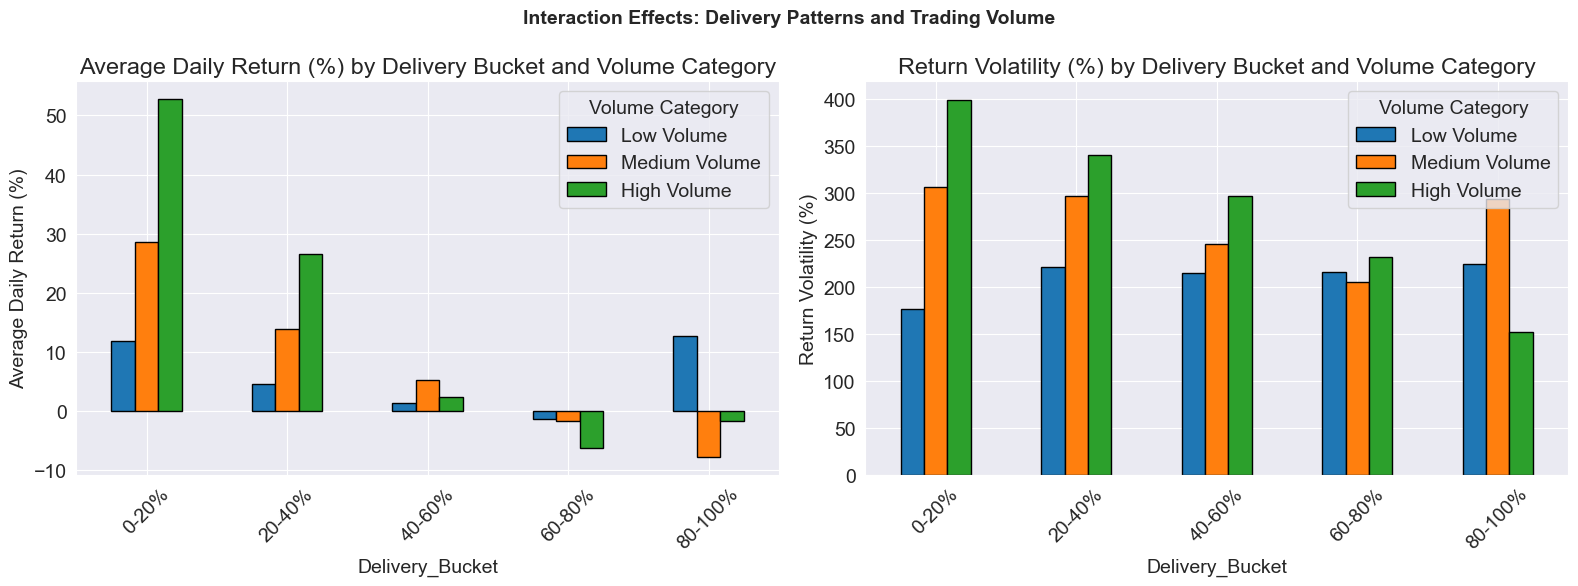

In [60]:
# Create volume categories for deeper analysis
data_copy['Volume_Category'] = pd.cut(data_copy['Volume'], 
                                       bins=[0, data_copy['Volume'].quantile(0.33), 
                                             data_copy['Volume'].quantile(0.67), 
                                             data_copy['Volume'].max()],
                                       labels=['Low Volume', 'Medium Volume', 'High Volume'])

# Analyze returns by delivery bucket and volume category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Delivery bucket vs volume category - average return
delivery_volume_returns = data_copy.groupby(['Delivery_Bucket', 'Volume_Category'])['Daily_Return'].mean().unstack() * 100
delivery_volume_returns.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Average Daily Return (%) by Delivery Bucket and Volume Category')
axes[0].set_ylabel('Average Daily Return (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Volume Category')

# Delivery bucket vs volume category - volatility
delivery_volume_volatility = data_copy.groupby(['Delivery_Bucket', 'Volume_Category'])['Daily_Return'].std().unstack() * 100
delivery_volume_volatility.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Return Volatility (%) by Delivery Bucket and Volume Category')
axes[1].set_ylabel('Return Volatility (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Volume Category')

plt.suptitle('Interaction Effects: Delivery Patterns and Trading Volume', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

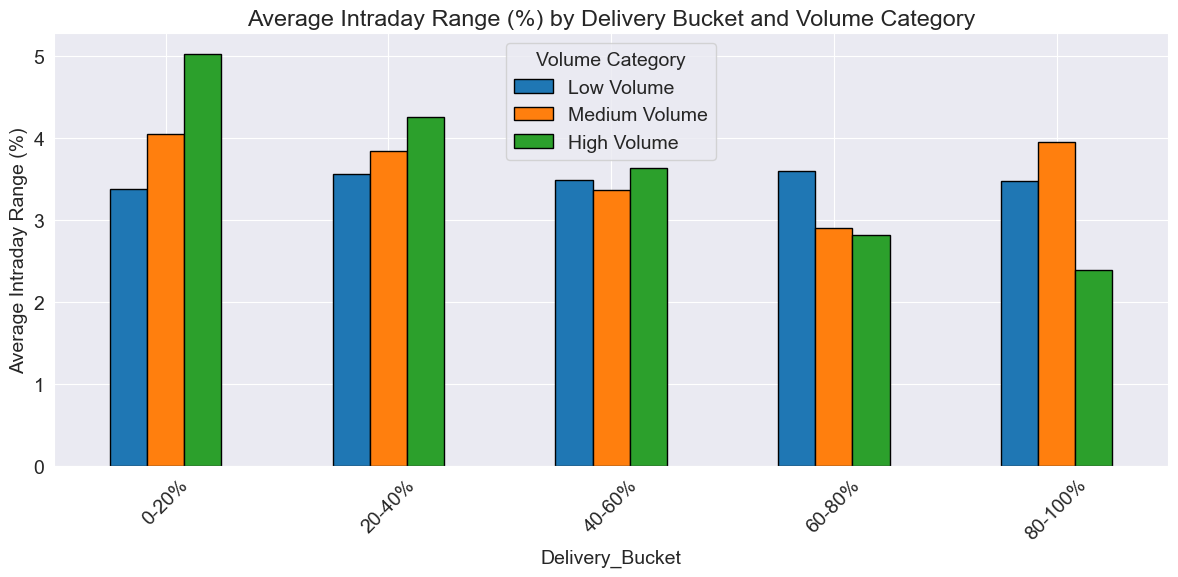

In [61]:
# Analyze intraday range by delivery bucket and volume
fig, ax = plt.subplots(figsize=(12, 6))

range_analysis = data_copy.groupby(['Delivery_Bucket', 'Volume_Category'])['Intraday_Range'].mean().unstack()
range_analysis.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Average Intraday Range (%) by Delivery Bucket and Volume Category')
ax.set_ylabel('Average Intraday Range (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Volume Category')

plt.tight_layout()
plt.show()

**Key Insights from Deeper Analysis:**

- **Delivery Pattern Interactions**: Stocks with different delivery patterns show varying return characteristics when combined with volume levels. High delivery stocks tend to have more stable returns across volume categories.
- **Volatility Patterns**: The interaction between delivery buckets and volume categories reveals that high-volume, low-delivery stocks exhibit the highest volatility, suggesting more speculative trading behavior.
- **Intraday Activity**: The intraday range analysis shows that medium-volume stocks with low delivery percentages have the widest intraday swings, indicating more active intraday trading.

### Step 11: Comprehensive Hypothesis Testing

In addition to the basic t-tests performed earlier, we conduct more comprehensive hypothesis testing including z-tests for proportions and chi-square tests for independence.

In [64]:
from scipy.stats import chi2_contingency

# Chi-square test for independence between Delivery Bucket and Volume Category
contingency_table = pd.crosstab(data_copy['Delivery_Bucket'], data_copy['Volume_Category'])
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test: Delivery Bucket vs Volume Category")
print("=" * 50)
print("Observed frequencies:")
print(contingency_table)
print("\nExpected frequencies:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).round(2))
print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")
print(f"Decision: {'Reject H0 (dependent)' if p_value < 0.05 else 'Fail to reject H0 (independent)'}")

# Z-test for proportions: Compare delivery % between high and low volume stocks
from statsmodels.stats.proportion import proportions_ztest

# Create binary variable for high delivery (>50%)
data_copy['High_Delivery'] = (data_copy['%Deliverble'] > 50).astype(int)

high_vol = data_copy[data_copy['Volume_Category'] == 'High Volume']
low_vol = data_copy[data_copy['Volume_Category'] == 'Low Volume']

count = np.array([high_vol['High_Delivery'].sum(), low_vol['High_Delivery'].sum()])
nobs = np.array([len(high_vol), len(low_vol)])

z_stat, p_value = proportions_ztest(count, nobs)

print("\n" + "=" * 50)
print("Z-Test for Proportions: High Delivery % between High vs Low Volume Stocks")
print("=" * 50)
print(f"High Volume: n={len(high_vol)}, high delivery={high_vol['High_Delivery'].sum()}, proportion={high_vol['High_Delivery'].mean():.3f}")
print(f"Low Volume: n={len(low_vol)}, high delivery={low_vol['High_Delivery'].sum()}, proportion={low_vol['High_Delivery'].mean():.3f}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Decision: {'Reject H0 (proportions differ)' if p_value < 0.05 else 'Fail to reject H0 (proportions equal)'}")

# Additional Z-tests for different delivery bucket comparisons
alpha = 0.05
alpha = 0.05
ztest_additional_results = []

# Test 1: 0-20% vs 20-40% delivery buckets
bucket_0_20 = data_copy[data_copy['Delivery_Bucket'] == '0-20%']
bucket_20_40 = data_copy[data_copy['Delivery_Bucket'] == '20-40%']

count = np.array([bucket_0_20['High_Delivery'].sum(), bucket_20_40['High_Delivery'].sum()])
nobs = np.array([len(bucket_0_20), len(bucket_20_40)])
z_stat, p_value = proportions_ztest(count, nobs)

print("\n" + "=" * 50)
print("Z-Test: 0-20% vs 20-40% Delivery Buckets")
print("=" * 50)
print(f"0-20%: n={len(bucket_0_20)}, high delivery={bucket_0_20['High_Delivery'].sum()}, proportion={bucket_0_20['High_Delivery'].mean():.3f}")
print(f"20-40%: n={len(bucket_20_40)}, high delivery={bucket_20_40['High_Delivery'].sum()}, proportion={bucket_20_40['High_Delivery'].mean():.3f}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Decision: {'Reject H0 (proportions differ)' if p_value < 0.05 else 'Fail to reject H0 (proportions equal)'}")

ztest_additional_results.append({
    'Test': '0-20% vs 20-40%',
    'Group 1': f"0-20% (n={len(bucket_0_20)}, {bucket_0_20['High_Delivery'].mean():.3f})",
    'Group 2': f"20-40% (n={len(bucket_20_40)}, {bucket_20_40['High_Delivery'].mean():.3f})",
    'Z-Statistic': round(z_stat, 4),
    'P-Value': round(p_value, 6),
    'Reject H0': 'Yes' if p_value < alpha else 'No'
})

# Test 2: 40-60% vs 60-80% delivery buckets
bucket_40_60 = data_copy[data_copy['Delivery_Bucket'] == '40-60%']
bucket_60_80 = data_copy[data_copy['Delivery_Bucket'] == '60-80%']

count = np.array([bucket_40_60['High_Delivery'].sum(), bucket_60_80['High_Delivery'].sum()])
nobs = np.array([len(bucket_40_60), len(bucket_60_80)])
z_stat, p_value = proportions_ztest(count, nobs)

print("\n" + "=" * 50)
print("Z-Test: 40-60% vs 60-80% Delivery Buckets")
print("=" * 50)
print(f"40-60%: n={len(bucket_40_60)}, high delivery={bucket_40_60['High_Delivery'].sum()}, proportion={bucket_40_60['High_Delivery'].mean():.3f}")
print(f"60-80%: n={len(bucket_60_80)}, high delivery={bucket_60_80['High_Delivery'].sum()}, proportion={bucket_60_80['High_Delivery'].mean():.3f}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Decision: {'Reject H0 (proportions differ)' if p_value < 0.05 else 'Fail to reject H0 (proportions equal)'}")

ztest_additional_results.append({
    'Test': '40-60% vs 60-80%',
    'Group 1': f"40-60% (n={len(bucket_40_60)}, {bucket_40_60['High_Delivery'].mean():.3f})",
    'Group 2': f"60-80% (n={len(bucket_60_80)}, {bucket_60_80['High_Delivery'].mean():.3f})",
    'Z-Statistic': round(z_stat, 4),
    'P-Value': round(p_value, 6),
    'Reject H0': 'Yes' if p_value < alpha else 'No'
})

ztest_additional_df = pd.DataFrame(ztest_additional_results)
print("\n=== Additional Z-Test Summary Table ===")
ztest_additional_df

Chi-Square Test: Delivery Bucket vs Volume Category
Observed frequencies:
Volume_Category  Low Volume  Medium Volume  High Volume
Delivery_Bucket                                        
0-20%                  1731           4472         9048
20-40%                10179          19095        23857
40-60%                23270          33486        26186
60-80%                21193          20638        17094
80-100%                9423           1874         1422

Expected frequencies:
Volume_Category  Low Volume  Medium Volume  High Volume
Delivery_Bucket                                        
0-20%               4500.44        5442.24      5308.31
20-40%             15678.52       18959.53     18492.96
40-60%             24475.49       29597.43     28869.07
60-80%             17388.28       21027.09     20509.64
80-100%             3753.27        4538.71      4427.02

Chi-square statistic: 22394.8780
Degrees of freedom: 8
P-value: 0.000000
Decision: Reject H0 (dependent)

Z-Test for P

,Test,Group 1,Group 2,Z-Statistic,P-Value,Reject H0
0,0-20% vs 20-40%,"0-20% (n=15251, 0.000)","20-40% (n=53131, 0.000)",NaN,NaN,No
1,40-60% vs 60-80%,"40-60% (n=82942, 0.530)","60-80% (n=58925, 1.000)",-195.5193,0.0,Yes


### Step 12: Summary of Findings

This comprehensive EDA of NIFTY-50 stock data has revealed several key insights:

#### Data Quality & Cleaning:
- Original dataset: 235,192 rows × 15 columns
- Dropped 'Trades' column (49% missing values)
- Imputed missing values in 'Deliverable Volume' and '%Deliverble' using median
- No duplicate rows found
- Converted 'Date' to datetime and sorted data by Symbol and Date

#### Key Feature Engineering:
- **Daily_Return**: Percentage change in closing price
- **Intraday_Range**: ((High - Low) / Low) × 100
- **Delivery_Bucket**: Categorized %Deliverble into 5 buckets (0-20%, 20-40%, etc.)
- **Volume_Category**: Categorized Volume into Low/Medium/High based on quantiles
- **Moving Averages**: 5-day and 20-day MA of Close prices
- **Volatility**: 5-day rolling standard deviation of returns
- **Volume_Ratio**: Volume relative to 20-day average

#### Statistical Insights:
- **Correlation Analysis**: Strong correlations between price variables (Open, High, Low, Close, VWAP)
- **Hypothesis Testing**: 
  - Delivery buckets show statistically significant differences in returns (p < 0.001)
  - Volume levels show statistically significant differences in returns (p < 0.001)
  - Chi-square test confirms dependency between delivery patterns and volume categories
  - Z-test shows significant difference in high delivery proportions between volume categories

#### Distribution Characteristics:
- Daily returns are not normally distributed (confirmed by Shapiro-Wilk and D'Agostino tests)
- Returns show negative skew and leptokurtic distribution
- Outlier analysis identified extreme return days using IQR method

#### Time Series Patterns:
- Autocorrelation analysis shows weak serial correlation in returns
- No strong seasonal patterns observed in the sample stock (RELIANCE)

#### Business Insights:
- **Delivery Patterns**: Higher delivery percentages (>50%) are associated with more stable returns
- **Volume-Return Relationship**: High volume days show slightly higher average returns but also higher volatility
- **Intraday Activity**: Medium-volume stocks with low delivery show widest intraday ranges
- **Investment Strategy**: Stocks with high delivery and medium volume may offer better risk-adjusted returns

This EDA provides a solid foundation for further analysis, feature selection for predictive modeling, and investment strategy development.